# Province focus Tambon Impact (Gold)

## Notebook Summary
This notebook contains the extracted analysis for Chiang Rai province from the national tambon impact study. 
It includes:
- Chiang Rai focus on tambon percentiles relative to the national distribution.
- Histograms of percentile metrics across Chiang Rai tambons.
- Time series analysis of yearly impact metrics.

**Source:** `ddpm_national_tambon_impact_2560_2567.ipynb` (Section 6)


# DDPM National Tambon Impact (Gold) — Climate Hazards | B.E. 2560–2567

Phase 2 notebook (read-only over Gold facts):
- Reads Gold fact tables built by [`build_gold_ddpm_tambon_impact_climate_2560_2567.py`](../ELT/build_gold_ddpm_tambon_impact_climate_2560_2567.py:1)
- Joins to Silver enriched tambon geometry by **6-digit DOPA code only** (`subdistrict_code` ↔ `subdist_cd`)
- Visualizes **whole-country** choropleths for each available metric

Guardrails:
- No name-based fallback joins
- Names are taken from the Gold spine (already embedded into the Gold fact table)


In [1]:
from __future__ import annotations

import sys
import re
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

# --- Thai text rendering (best-effort) ---
thai_font_candidates = [
    'TH Sarabun New',
    'Sarabun',
    'Noto Sans Thai',
    'Tahoma',
    'Angsana New',
    'Cordia New',
]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
thai_font = next((_f for _f in thai_font_candidates if _f in available_fonts), None)
if thai_font is not None:
    mpl.rcParams['font.family'] = thai_font
mpl.rcParams['axes.unicode_minus'] = False

# --- Global readability tuning: +2pt across the board ---
mpl.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
})

# Notebook-relative root (data_system/)
BASE_PATH = Path.cwd().resolve().parent.parent  # .../data_system
print('BASE_PATH =', BASE_PATH)

FACT_PATH = BASE_PATH / 'data/2_gold/ddpm/fact_ddpm_tambon_impact_climate_2560_2567.csv'
YEARLY_PATH = BASE_PATH / 'data/2_gold/ddpm/fact_ddpm_tambon_impact_climate_yearly_2560_2567.csv'
TAMBON_SHP_PATH = BASE_PATH / 'data/1_silver/dopa/tambon_boundaries_enriched.shp'
PROVINCE_BRONZE_SHP_PATH = BASE_PATH / 'data/0_bronze/dopa/thailanda-administrative-boundary/THA_Province.shp'

assert FACT_PATH.exists(), FACT_PATH
assert YEARLY_PATH.exists(), YEARLY_PATH
assert TAMBON_SHP_PATH.exists(), TAMBON_SHP_PATH
assert PROVINCE_BRONZE_SHP_PATH.exists(), PROVINCE_BRONZE_SHP_PATH


BASE_PATH = C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system


## Load Gold facts + Silver geometry
We will join by code only:
- Gold: `subdistrict_code` (6 digits)
- Geometry: `subdist_cd` (6 digits)


In [2]:
def _read_csv_flex(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp874')

def _extract_digits(value: object) -> str:
    if value is None:
        return ''
    s = str(value).strip()
    m = re.search(r'(\d+)', s)
    return m.group(1) if m else ''

def _clean_code_6(series: pd.Series) -> pd.Series:
    s = series.astype(str)
    s = s.str.replace(r'\.0$', '', regex=True).str.strip()
    s = s.map(_extract_digits)
    s = s.str[-6:].fillna('')
    s = s.where(s.str.fullmatch(r'\d{6}', na=False), '')
    s = s.where(~s.isin(['', '000000', 'nan', 'None']), '')
    return s

fact = _read_csv_flex(FACT_PATH)
yearly = _read_csv_flex(YEARLY_PATH)
gdf = gpd.read_file(TAMBON_SHP_PATH)
gdf_prov_bronze = gpd.read_file(PROVINCE_BRONZE_SHP_PATH)

print('fact.shape =', fact.shape)
print('yearly.shape =', yearly.shape)
print('gdf.shape =', gdf.shape)
print('gdf_prov_bronze.shape =', gdf_prov_bronze.shape)

required_fact_cols = {'subdistrict_code'}
missing = required_fact_cols.difference(fact.columns)
if missing:
    raise KeyError(f'Missing columns in fact: {sorted(missing)}')
if 'subdist_cd' not in gdf.columns:
    raise KeyError("Geometry is missing 'subdist_cd'. Columns: " + str(list(gdf.columns)))

fact = fact.copy()
fact['subdistrict_code'] = _clean_code_6(fact['subdistrict_code'])
fact = fact.loc[fact['subdistrict_code'].ne('')].copy()

gdf = gdf.copy()
gdf['subdist_cd'] = _clean_code_6(gdf['subdist_cd'])
gdf = gdf.loc[gdf['subdist_cd'].ne('')].copy()

# Keep geometry lean for plotting performance
geom_keep_cols = ['subdist_cd', 'P_NAME_T', 'A_NAME_T', 'T_NAME_T', 'geometry']
geom_keep_cols = [c for c in geom_keep_cols if c in gdf.columns]
gdf = gdf[geom_keep_cols].copy()

# Bronze province boundaries for overlay (visual only)
gdf_prov_bronze = gdf_prov_bronze.to_crs(gdf.crs)
prov_keep_cols = ['geometry']
if 'P_CODE' in gdf_prov_bronze.columns: prov_keep_cols.insert(0, 'P_CODE')
if 'P_NAME_T' in gdf_prov_bronze.columns: prov_keep_cols.insert(0, 'P_NAME_T')
gdf_prov_bronze = gdf_prov_bronze[prov_keep_cols].copy()

# Join for mapping (left join from geometry is OK; missing stats => 0 for maps)
map_df = gdf.merge(fact, left_on='subdist_cd', right_on='subdistrict_code', how='left')
print('map_df.shape =', map_df.shape)


fact.shape = (6967, 13)
yearly.shape = (55736, 8)
gdf.shape = (8125, 10)
gdf_prov_bronze.shape = (77, 4)
map_df.shape = (8125, 18)


## National integrity checks (non-negotiable)
This notebook re-checks the hard QA property that should already hold from the Gold build:
- `stats_codes ⊆ geometry_codes`


In [3]:
stat_codes = set(fact['subdistrict_code'].unique().tolist())
geom_codes = set(gdf['subdist_cd'].unique().tolist())
missing_geom = sorted(stat_codes.difference(geom_codes))
print('Unique stat codes   =', len(stat_codes))
print('Unique geometry codes=', len(geom_codes))
print('Missing geometry codes (should be 0) =', len(missing_geom))
if missing_geom:
    display(pd.DataFrame({'subdistrict_code': missing_geom}).head(50))
    raise RuntimeError(f'Stats→geometry coverage failed inside notebook: {len(missing_geom)} missing codes')

# Quick duplicate checks
dup_fact = int(fact['subdistrict_code'].duplicated().sum())
dup_geom = int(gdf['subdist_cd'].duplicated().sum())
print('Duplicate subdistrict_code rows in fact:', dup_fact)
print('Duplicate subdist_cd rows in geometry (expected >0? depends on shapefile):', dup_geom)


Unique stat codes   = 6967
Unique geometry codes= 7436
Missing geometry codes (should be 0) = 0
Duplicate subdistrict_code rows in fact: 0
Duplicate subdist_cd rows in geometry (expected >0? depends on shapefile): 689


## 1) Chiang Rai Specific Analysis
We use the yearly Gold output for trend plots.


### 1.1) Chiang Rai focus — tambon percentiles (relative to the whole country)
This section maps Chiang Rai tambons, but colors them using **national percentiles** already computed in the Gold fact table.

Metrics (percentile of whole country):
- `pct_national_affected_households_sum`
- `pct_national_affected_people_sum`
- `pct_national_deaths_sum`
- `pct_national_avg_yoy_change`

Top 10 tambons (within Chiang Rai) are annotated on each map.


Chiang Rai rows (geometry): 124


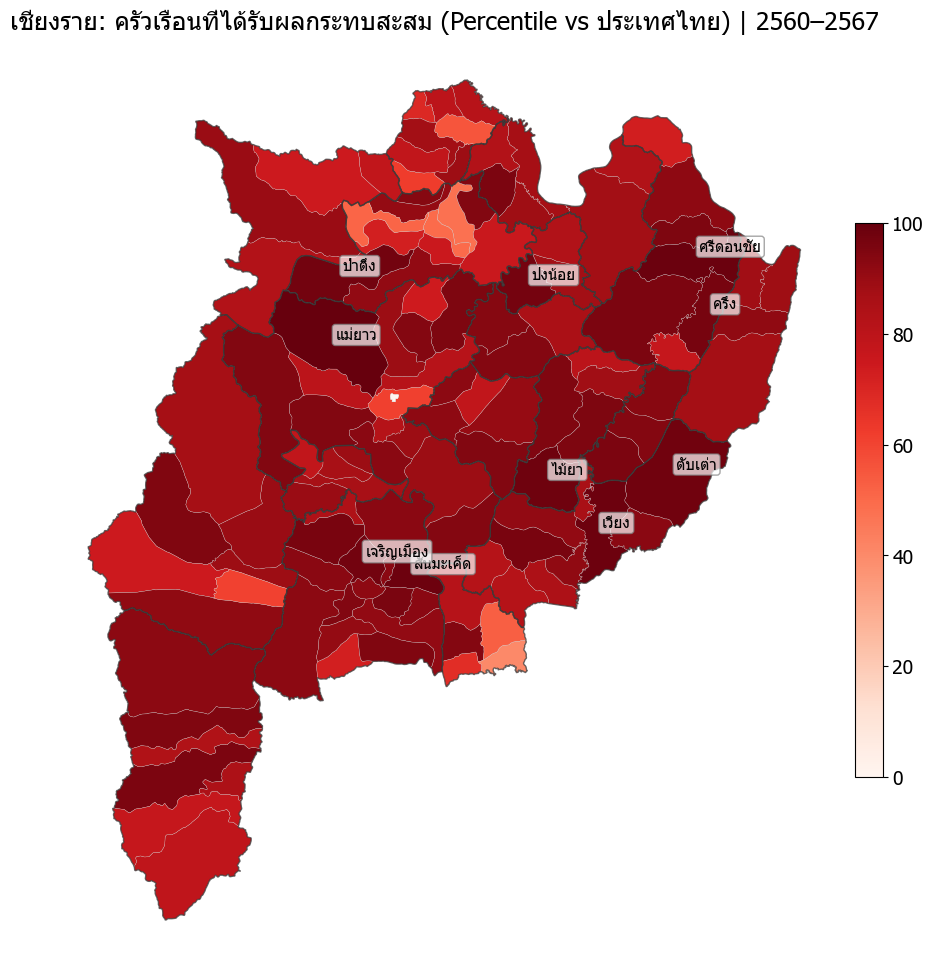

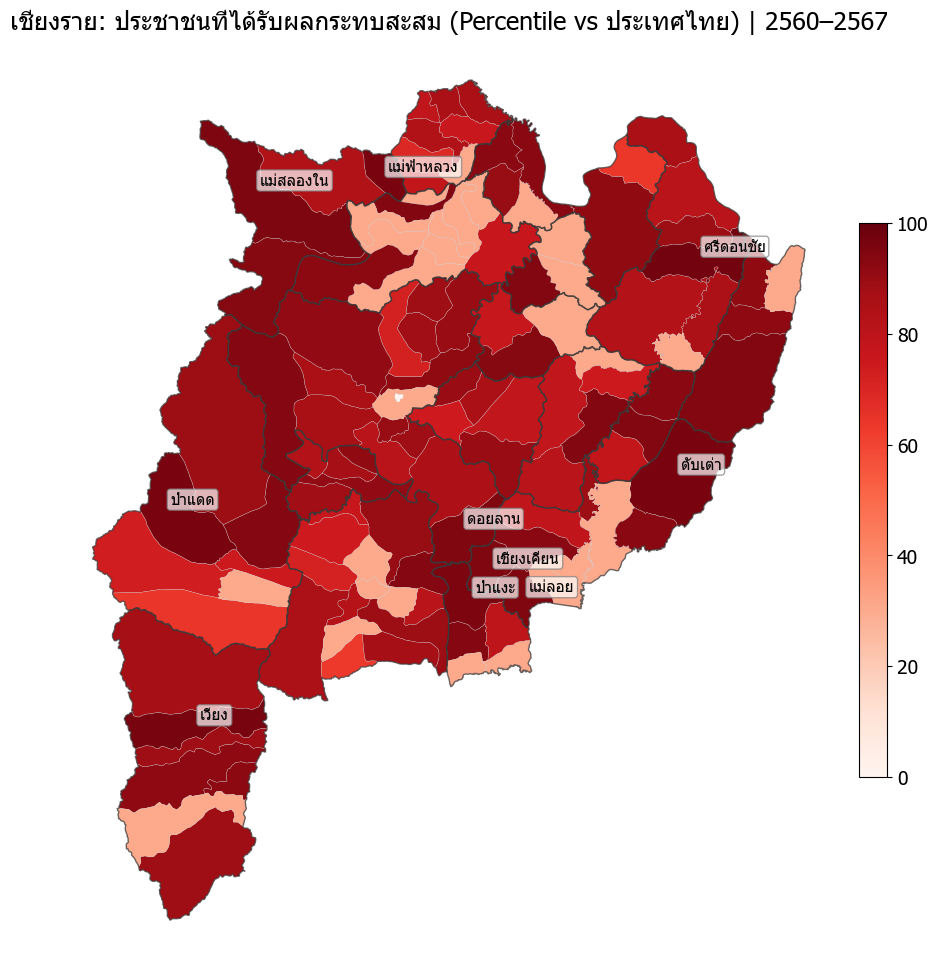

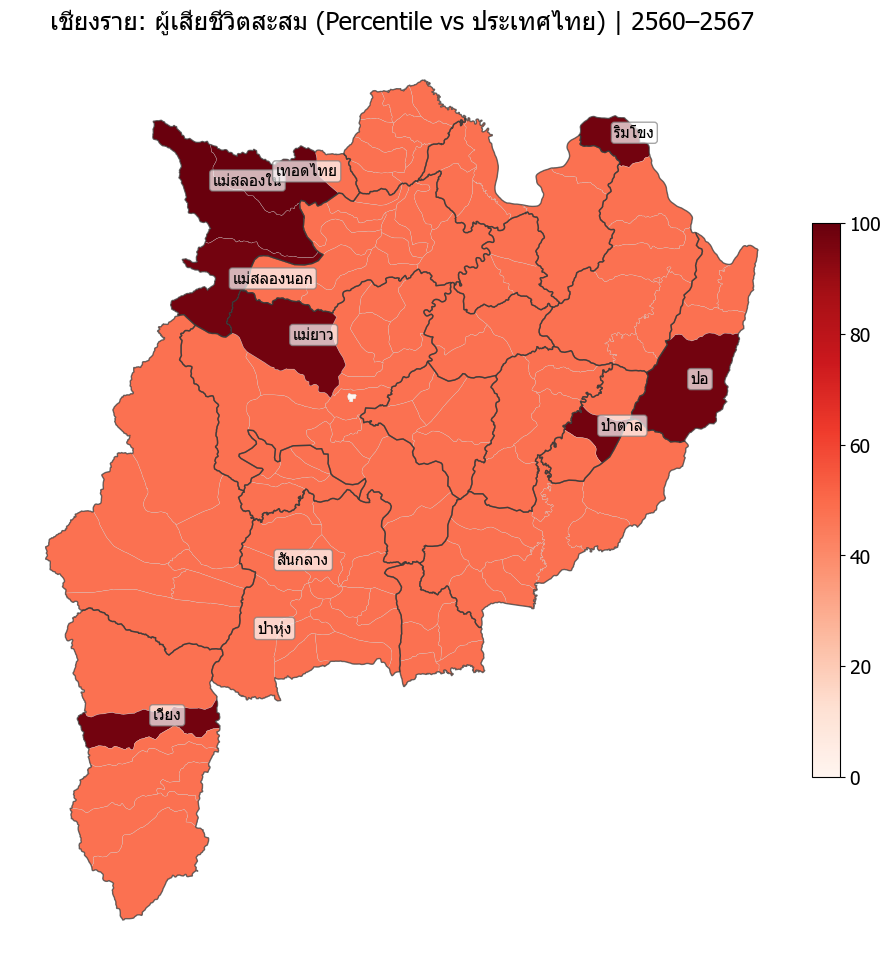

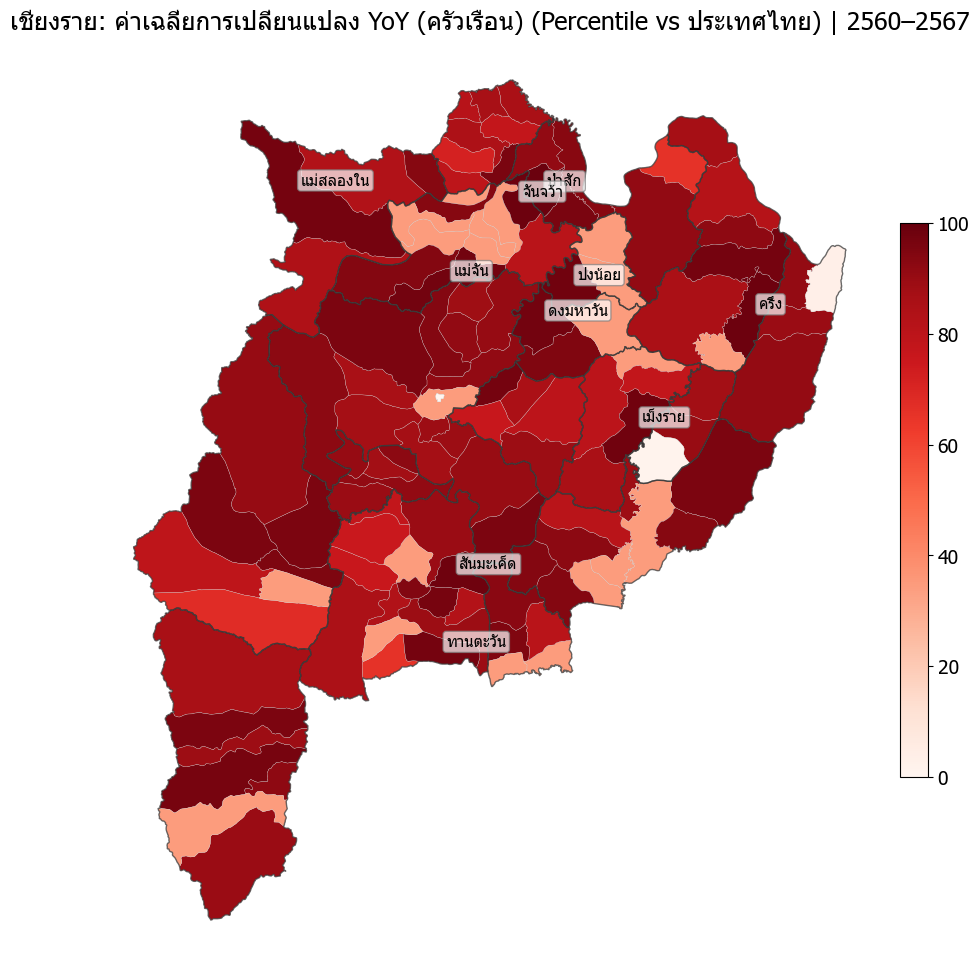

In [4]:
PROVINCE_CODE_CR = '57'

# Filter Chiang Rai geometry+metrics via code prefix only (no name fallback)
cr = map_df.loc[map_df['subdist_cd'].astype(str).str.startswith(PROVINCE_CODE_CR)].copy()
print('Chiang Rai rows (geometry):', len(cr))

# Percentile columns expected from Gold fact
pct_cols = [
    'pct_national_affected_households_sum',
    'pct_national_affected_people_sum',
    'pct_national_deaths_sum',
    'pct_national_avg_yoy_change',
]
missing_pct = [c for c in pct_cols if c not in cr.columns]
if missing_pct:
    raise KeyError('Missing percentile columns in joined map_df: ' + str(missing_pct))

# Ensure numeric
for c in pct_cols:
    cr[c] = pd.to_numeric(cr[c], errors='coerce').fillna(0.0)

# District boundaries for overlay (optional but makes maps readable)
districts_cr = None
if 'A_NAME_T' in cr.columns:
    try:
        districts_cr = cr.dissolve(by='A_NAME_T')
    except Exception:
        districts_cr = None

def _label_tambon(row: pd.Series) -> str:
    # Prefer authoritative Gold spine names if present; fallback to shapefile field
    for c in ['subdistrict_name_th', 'T_NAME_T']:
        if c in row and pd.notna(row[c]) and str(row[c]).strip():
            return str(row[c]).strip()
    return str(row.get('subdist_cd', '')).strip()

def plot_chiang_rai_percentile(metric_pct_col: str, title_th: str) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.set_axis_off()
    ax.set_title(f'เชียงราย: {title_th} (Percentile vs ประเทศไทย) | 2560–2567', fontsize=18)

    # Percentiles are computed at Gold build time across ALL tambons nationwide (0..100).
    cr.plot(
        column=metric_pct_col,
        ax=ax,
        cmap='Reds',
        legend=True,
        legend_kwds={
            'shrink': 0.6,
            'fraction': 0.03,
            'pad': 0.02,
        },
        vmin=0,
        vmax=100,
        linewidth=0.2,
        edgecolor='#CCCCCC',
    )

    if districts_cr is not None:
        try:
            districts_cr.boundary.plot(ax=ax, color='#333333', linewidth=1.0, alpha=0.7)
        except Exception:
            pass

    # Annotate top 10 tambons within Chiang Rai by percentile
    top10 = cr.sort_values(metric_pct_col, ascending=False).head(10).copy()
    for _, r in top10.iterrows():
        try:
            pt = r.geometry.representative_point()
            ax.annotate(
                text=_label_tambon(r),
                xy=(pt.x, pt.y),
                xytext=(3, 3),
                textcoords='offset points',
                fontsize=11,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='0.5'),
            )
        except Exception:
            continue

    plt.show()

chiang_rai_maps = [
    ('pct_national_affected_households_sum', 'ครัวเรือนที่ได้รับผลกระทบสะสม'),
    ('pct_national_affected_people_sum', 'ประชาชนที่ได้รับผลกระทบสะสม'),
    ('pct_national_deaths_sum', 'ผู้เสียชีวิตสะสม'),
    ('pct_national_avg_yoy_change', 'ค่าเฉลี่ยการเปลี่ยนแปลง YoY (ครัวเรือน)'),
]

for col, title_th in chiang_rai_maps:
    plot_chiang_rai_percentile(col, title_th)


### 1.2) Chiang Rai — histograms of percentile metrics (distribution across tambons)
These histograms show the **distribution of national percentiles (0–100)** for Chiang Rai tambons, for the same four metrics used in the maps.


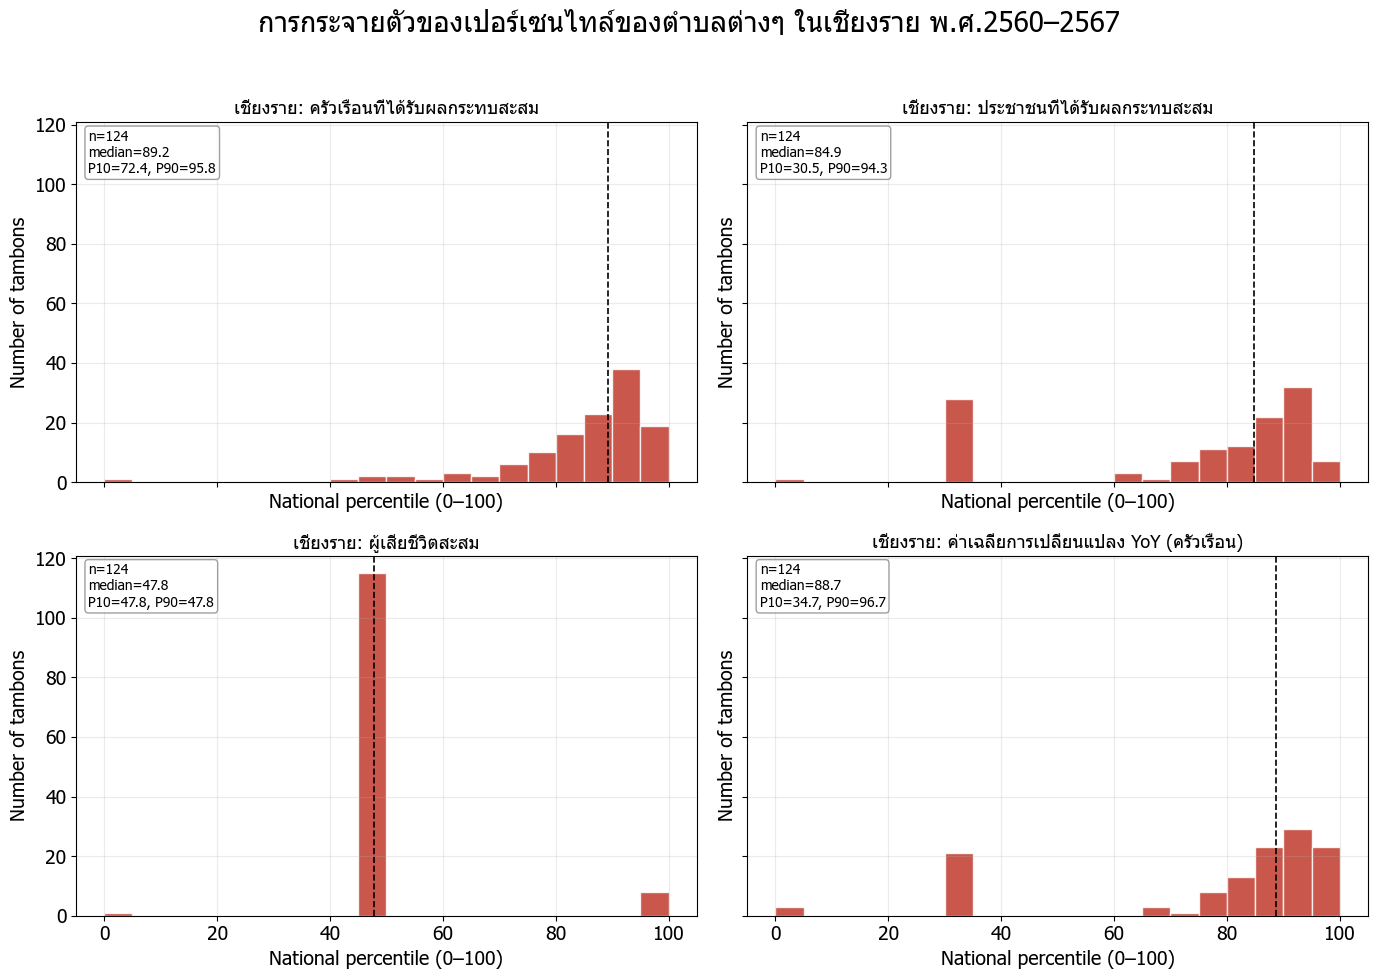

In [5]:
# Histograms for Chiang Rai percentile metrics (0..100)
# Requires: `cr` and `pct_cols` from the Chiang Rai mapping cell above

_cr_pct = cr[pct_cols].copy()
# Clip just in case upstream percentiles contain out-of-range values
_cr_pct = _cr_pct.apply(lambda s: pd.to_numeric(s, errors='coerce')).fillna(0.0).clip(0, 100)

title_map_th = {
    'pct_national_affected_households_sum': 'ครัวเรือนที่ได้รับผลกระทบสะสม',
    'pct_national_affected_people_sum': 'ประชาชนที่ได้รับผลกระทบสะสม',
    'pct_national_deaths_sum': 'ผู้เสียชีวิตสะสม',
    'pct_national_avg_yoy_change': 'ค่าเฉลี่ยการเปลี่ยนแปลง YoY (ครัวเรือน)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

for i, c in enumerate(pct_cols):
    ax = axes[i]
    vals = _cr_pct[c].dropna().values
    ax.hist(vals, bins=20, range=(0, 100), color='#c0392b', alpha=0.85, edgecolor='white')
    ax.set_title(f'เชียงราย: {title_map_th.get(c, c)}', fontsize=13)
    ax.set_xlabel('National percentile (0–100)')
    ax.set_ylabel('Number of tambons')
    ax.grid(True, alpha=0.25)

    # Summary lines
    if len(vals):
        q10, q50, q90 = np.percentile(vals, [10, 50, 90])
        ax.axvline(q50, color='black', linestyle='--', linewidth=1.2, label='median')
        ax.text(0.02, 0.98,
                f'n={len(vals)}\nmedian={q50:.1f}\nP10={q10:.1f}, P90={q90:.1f}',
                transform=ax.transAxes, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.75, ec='0.5'),
                fontsize=10)

plt.suptitle('การกระจายตัวของเปอร์เซนไทล์ของตำบลต่างๆ ในเชียงราย พ.ศ.2560–2567', fontsize=20)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


Yearly metric columns:
 - affected_households_sum
 - affected_people_sum
 - deaths_sum
 - province_code_x
 - province_code_y
 - yoy_delta_affected_households


,year_be,affected_households_sum,affected_people_sum,deaths_sum,province_code_x,province_code_y,yoy_delta_affected_households
0,2560,94783.0,0.0,29.0,24207.0,343758,0.0
1,2561,186927.0,0.0,42.0,154906.0,343758,92144.0
2,2562,461947.0,0.0,47.0,201840.0,343758,275020.0
3,2563,294881.0,0.0,38.0,179558.0,343758,-167066.0
4,2564,223256.0,0.0,49.0,199974.0,343758,-71625.0
5,2565,360156.0,4553.0,50.0,223635.0,343758,136900.0
6,2566,422059.0,596678.0,50.0,194538.0,343758,61903.0
7,2567,507316.0,885166.0,119.0,267631.0,343758,85257.0


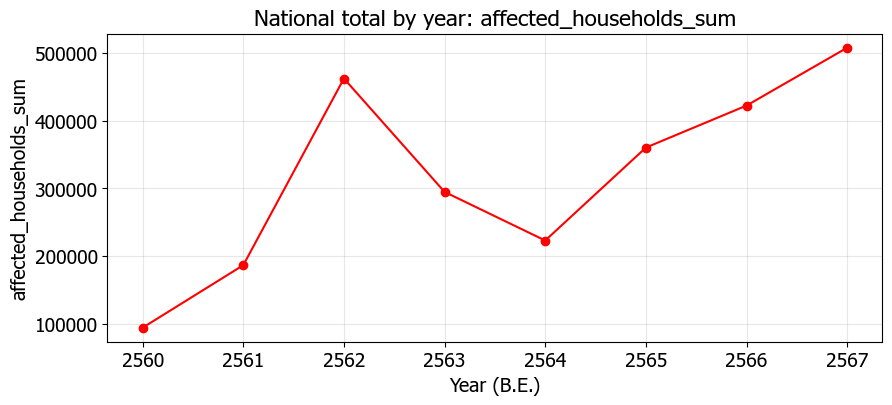

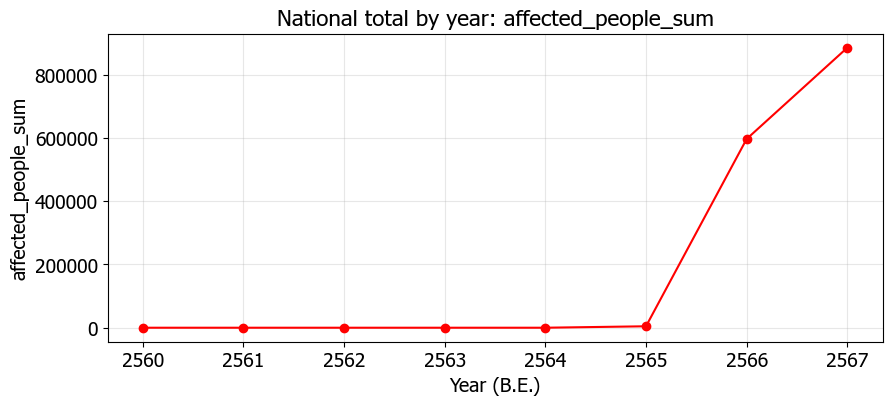

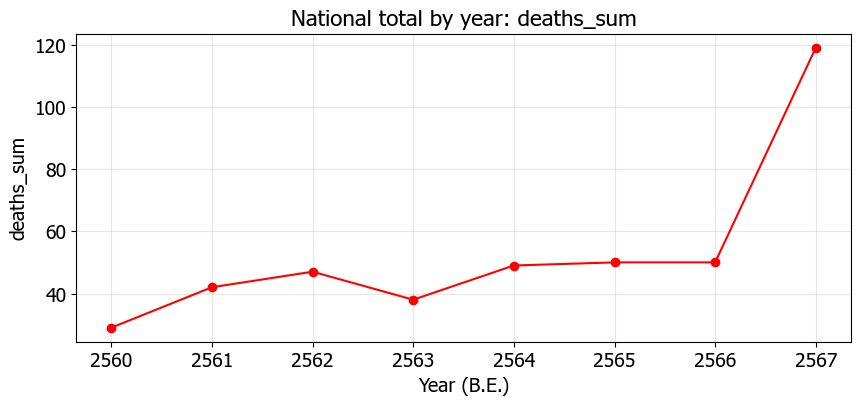

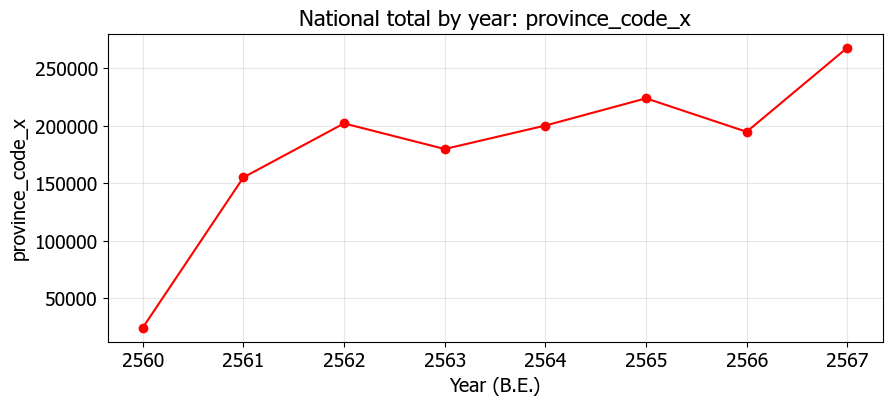

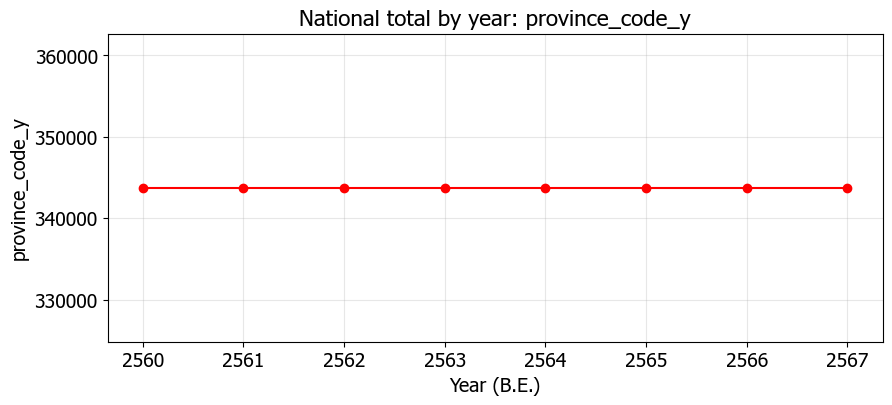

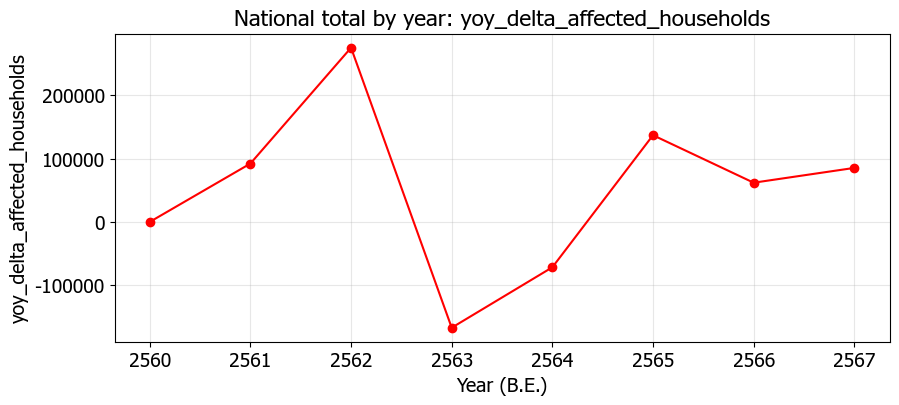

In [6]:
yearly = yearly.copy()
yearly['subdistrict_code'] = _clean_code_6(yearly.get('subdistrict_code', pd.Series(dtype=str)))
yearly['year_be'] = pd.to_numeric(yearly.get('year_be', pd.Series(dtype=float)), errors='coerce')
yearly = yearly.loc[yearly['subdistrict_code'].ne('')].copy()

# Discover yearly metric columns
yearly_id = {'subdistrict_code', 'province_code', 'year_be'}
yearly_metrics = [c for c in yearly.columns if c not in yearly_id and pd.api.types.is_numeric_dtype(yearly[c])]
yearly_metrics = sorted(yearly_metrics)
print('Yearly metric columns:')
for c in yearly_metrics:
    print(' -', c)

# National totals by year
nat_year = yearly.groupby('year_be', as_index=False).agg({m: 'sum' for m in yearly_metrics})
display(nat_year)

for m in yearly_metrics:
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.plot(nat_year['year_be'], nat_year[m], marker='o', color='red')
    ax.set_title(f'National total by year: {m}')
    ax.set_xlabel('Year (B.E.)')
    ax.set_ylabel(m)
    ax.grid(True, alpha=0.3)
    plt.show()


## 1.3) Chiang Rai focus — absolute impact values
This section visualizes the **raw impact counts** (absolute values) rather than national percentiles. 
This is useful for identifying the tambons with the highest total burden in Chiang Rai.

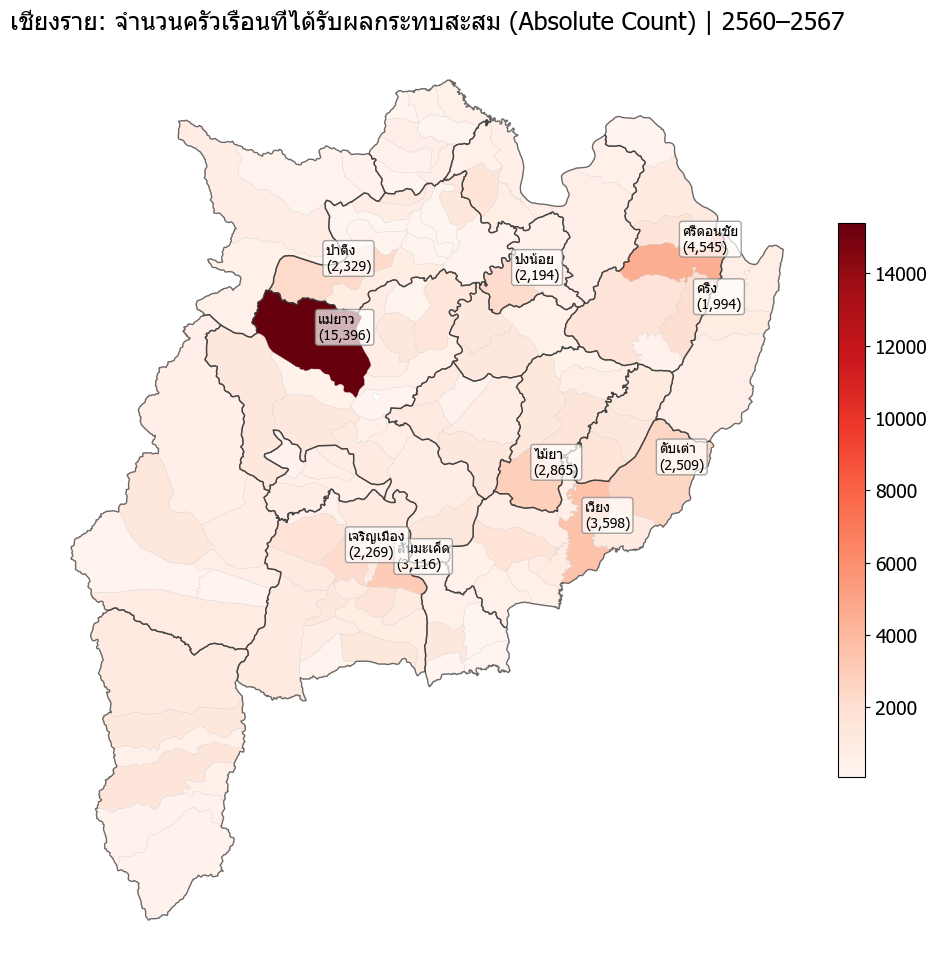

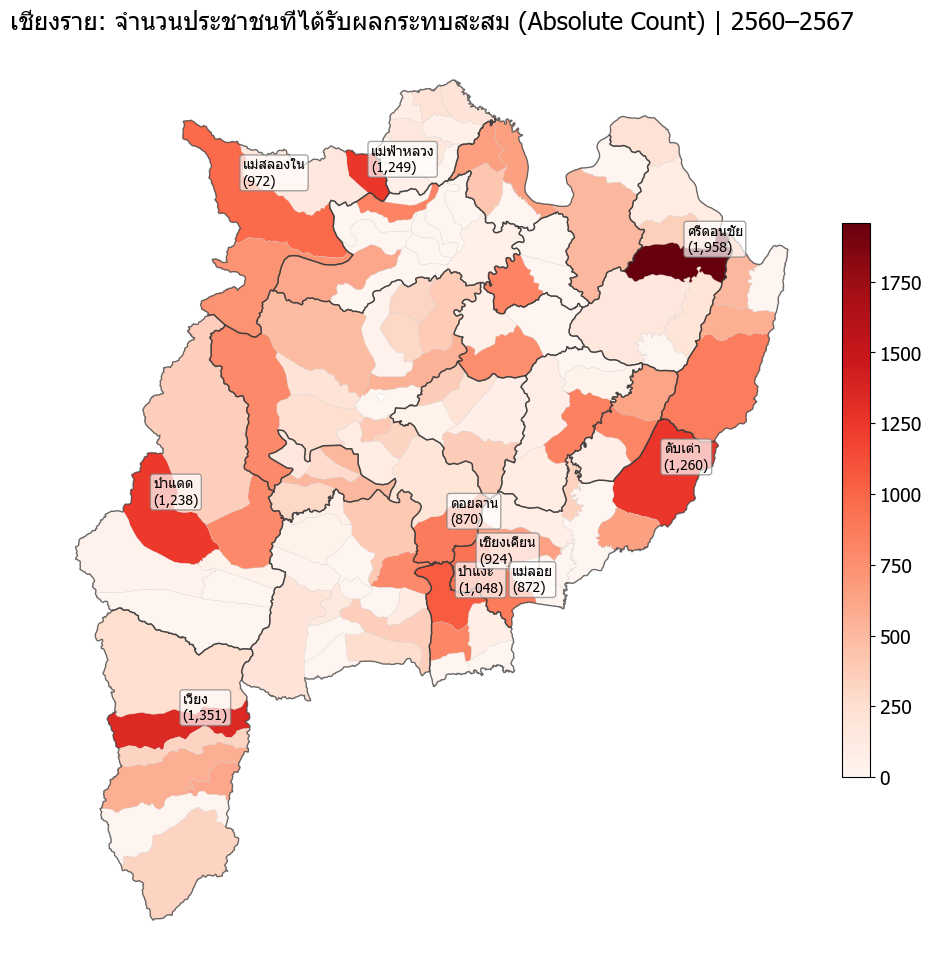

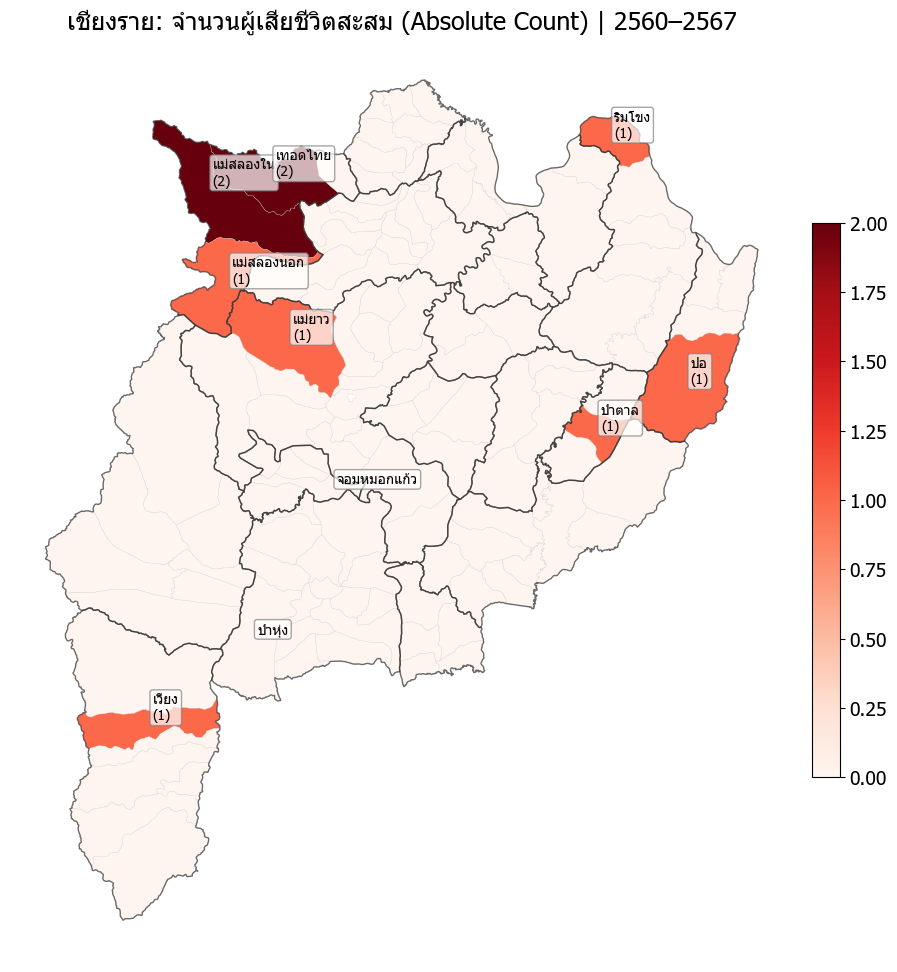

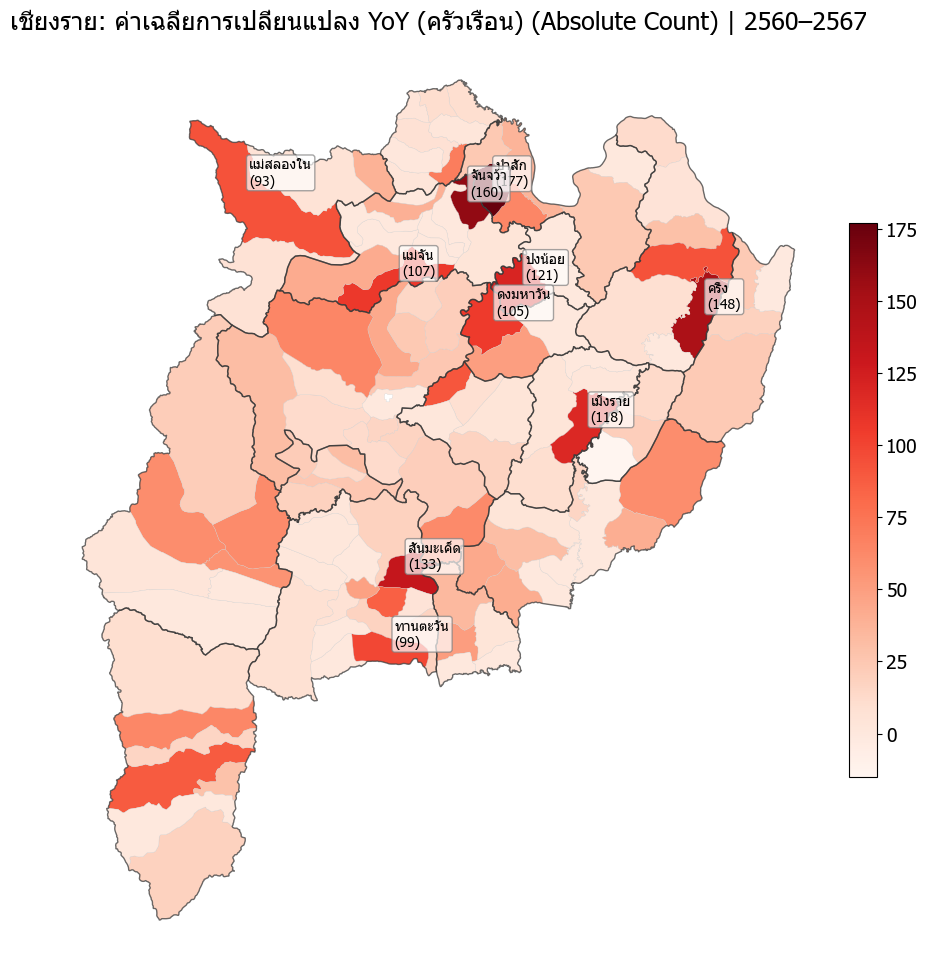

In [7]:
def plot_chiang_rai_absolute(metric_col: str, title_th: str) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.set_axis_off()
    ax.set_title(f'เชียงราย: {title_th} (Absolute Count) | 2560–2567', fontsize=18)

    # Plot absolute values with automatic scaling
    cr.plot(
        column=metric_col,
        ax=ax,
        cmap='Reds',
        legend=True,
        legend_kwds={
            'shrink': 0.6,
            'fraction': 0.03,
            'pad': 0.02,
        },
        linewidth=0.2,
        edgecolor='#CCCCCC',
    )

    if districts_cr is not None:
        try:
            districts_cr.boundary.plot(ax=ax, color='#333333', linewidth=1.0, alpha=0.7)
        except Exception:
            pass

    # Annotate top 10 tambons within Chiang Rai by absolute value
    top10 = cr.sort_values(metric_col, ascending=False).head(10).copy()
    for _, r in top10.iterrows():
        try:
            pt = r.geometry.representative_point()
            val = r[metric_col]
            label = f"{_label_tambon(r)}\n({val:,.0f})" if val >= 1 else _label_tambon(r)
            ax.annotate(
                text=label,
                xy=(pt.x, pt.y),
                xytext=(3, 3),
                textcoords='offset points',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='0.5'),
            )
        except Exception:
            continue

    plt.show()

abs_metrics = [
    ('affected_households_sum', 'จำนวนครัวเรือนที่ได้รับผลกระทบสะสม'),
    ('affected_people_sum', 'จำนวนประชาชนที่ได้รับผลกระทบสะสม'),
    ('deaths_sum', 'จำนวนผู้เสียชีวิตสะสม'),
    ('avg_yoy_change', 'ค่าเฉลี่ยการเปลี่ยนแปลง YoY (ครัวเรือน)'),
]

for col, title_th in abs_metrics:
    if col in cr.columns:
        plot_chiang_rai_absolute(col, title_th)
    else:
        print(f"Warning: Column {col} not found in 'cr' DataFrame.")

### D) Chiang Rai — histograms of absolute metrics
These histograms show the distribution of raw impact counts across Chiang Rai tambons.

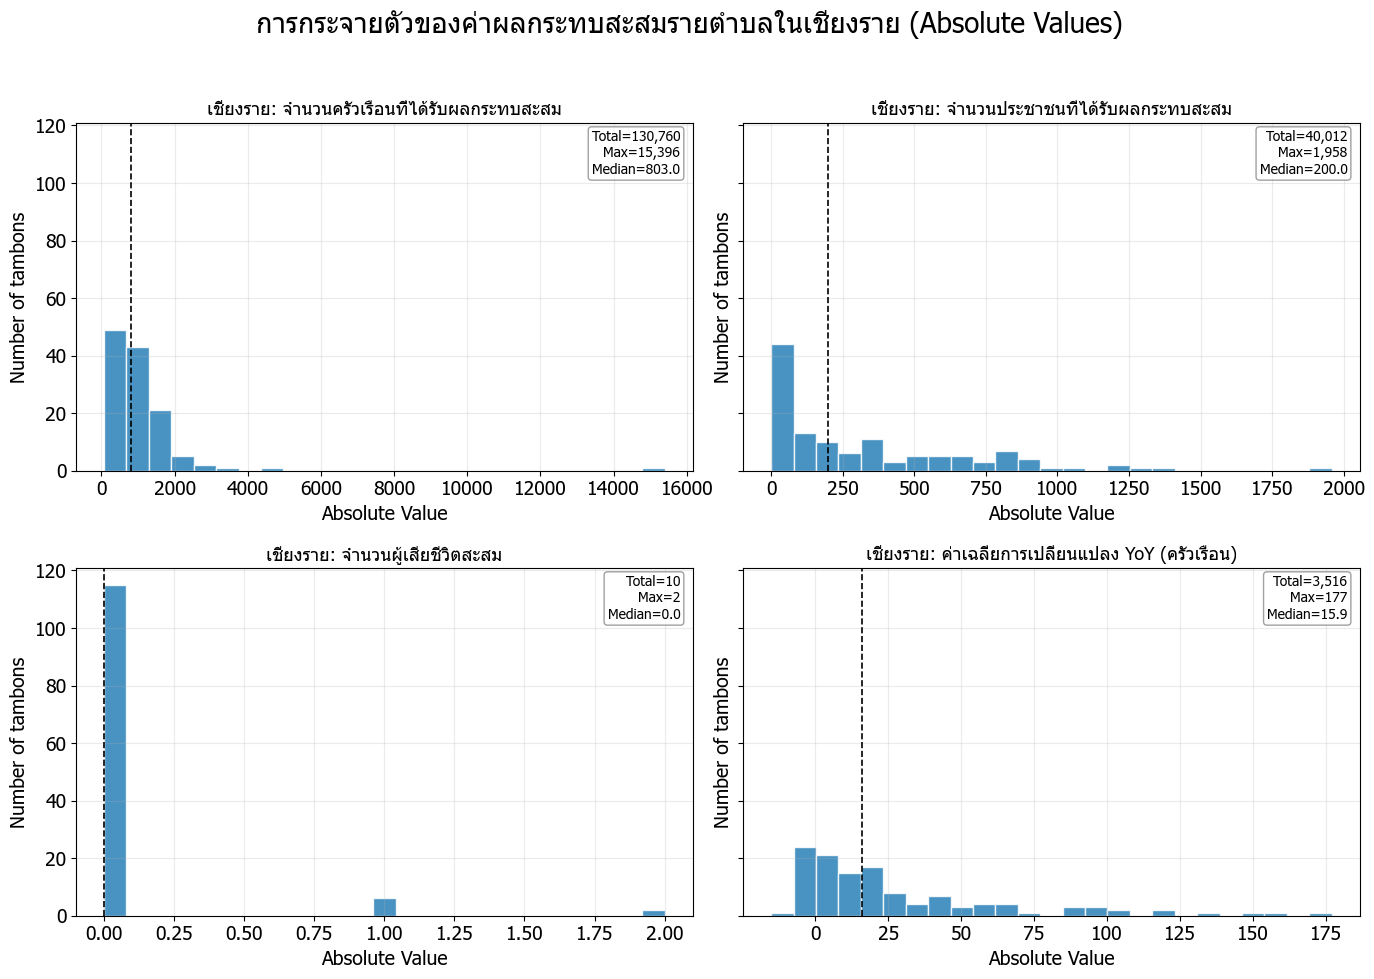

In [8]:
# Histograms for absolute metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.ravel()

for i, (col, title_th) in enumerate(abs_metrics):
    ax = axes[i]
    if col not in cr.columns:
        ax.set_title(f"Missing: {col}")
        continue
        
    vals = pd.to_numeric(cr[col], errors='coerce').dropna().values
    if len(vals) == 0:
        ax.set_title(f"No data: {title_th}")
        continue
        
    ax.hist(vals, bins=25, color='#2980b9', alpha=0.85, edgecolor='white')
    ax.set_title(f'เชียงราย: {title_th}', fontsize=13)
    ax.set_xlabel('Absolute Value')
    ax.set_ylabel('Number of tambons')
    ax.grid(True, alpha=0.25)

    # Summary statistics
    q50 = np.median(vals)
    ax.axvline(q50, color='black', linestyle='--', linewidth=1.2)
    ax.text(0.98, 0.98, 
            f'Total={np.sum(vals):,.0f}\nMax={np.max(vals):,.0f}\nMedian={q50:,.1f}',
            transform=ax.transAxes, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.75, ec='0.5'),
            fontsize=10)

plt.suptitle('การกระจายตัวของค่าผลกระทบสะสมรายตำบลในเชียงราย (Absolute Values)', fontsize=20)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 2) Nakhon Si Thammarat Specific Analysis
This section applies the same provincial impact analysis to Nakhon Si Thammarat.

### 2.1) Nakhon Si Thammarat focus — tambon percentiles (relative to the whole country)

Nakhon Si Thammarat rows (geometry): 171


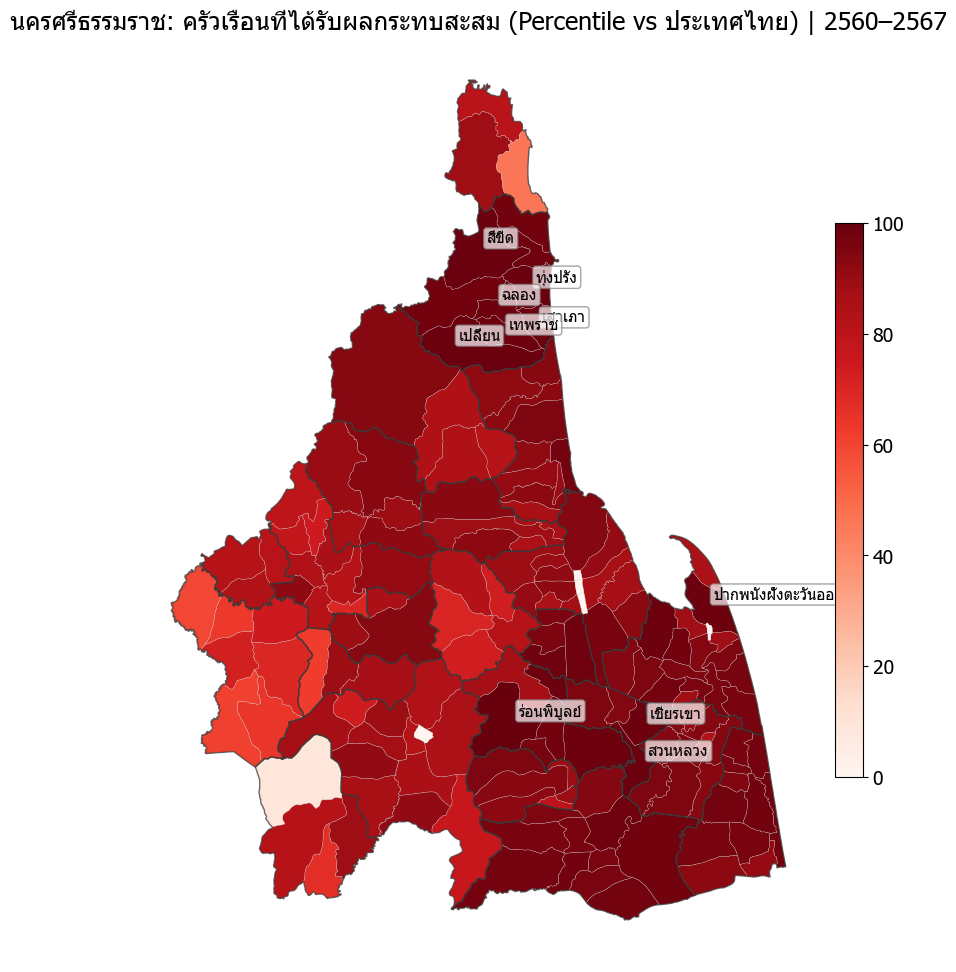

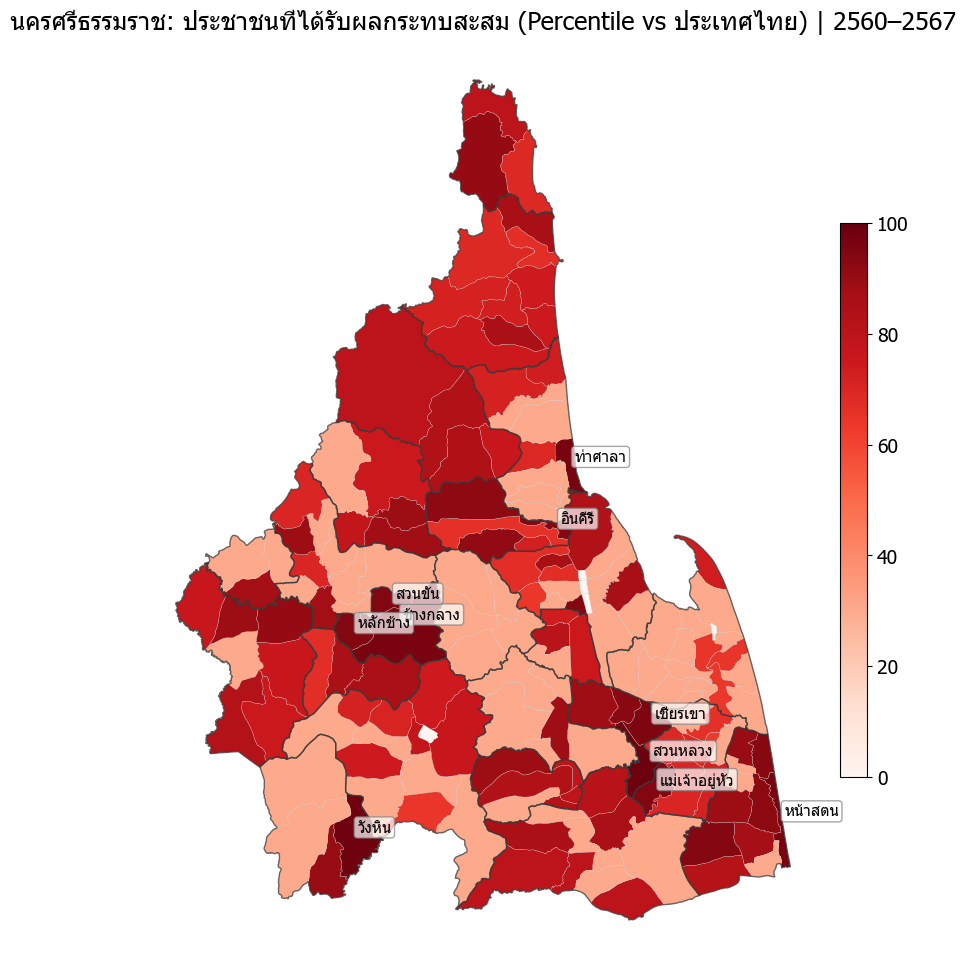

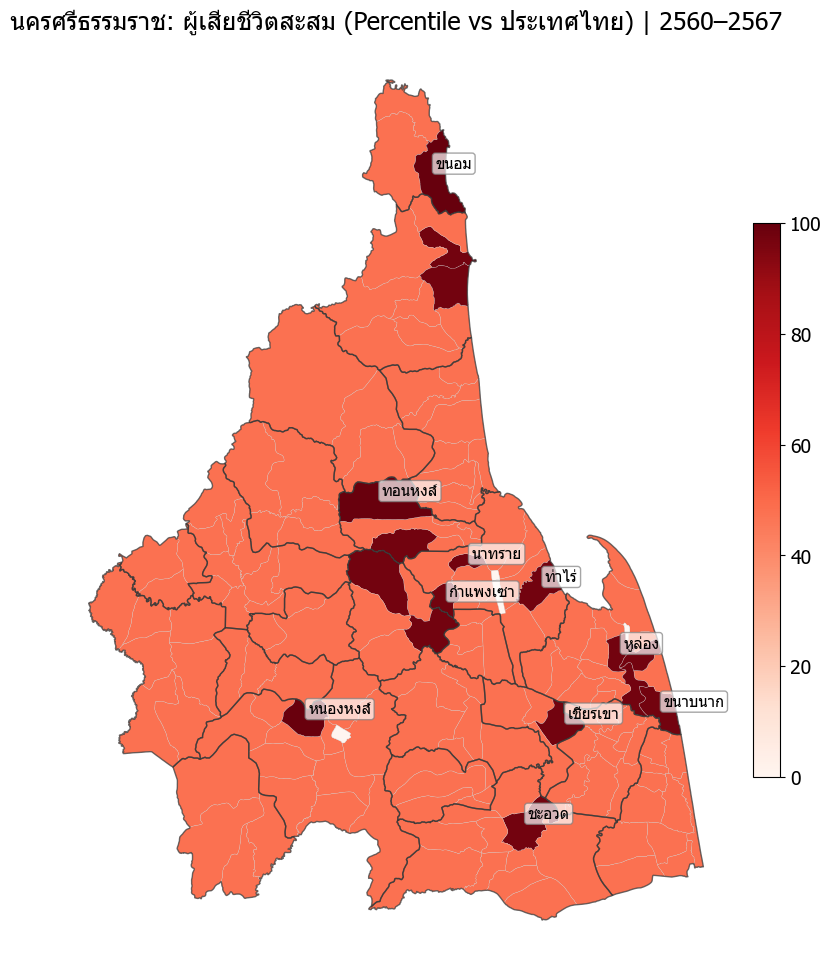

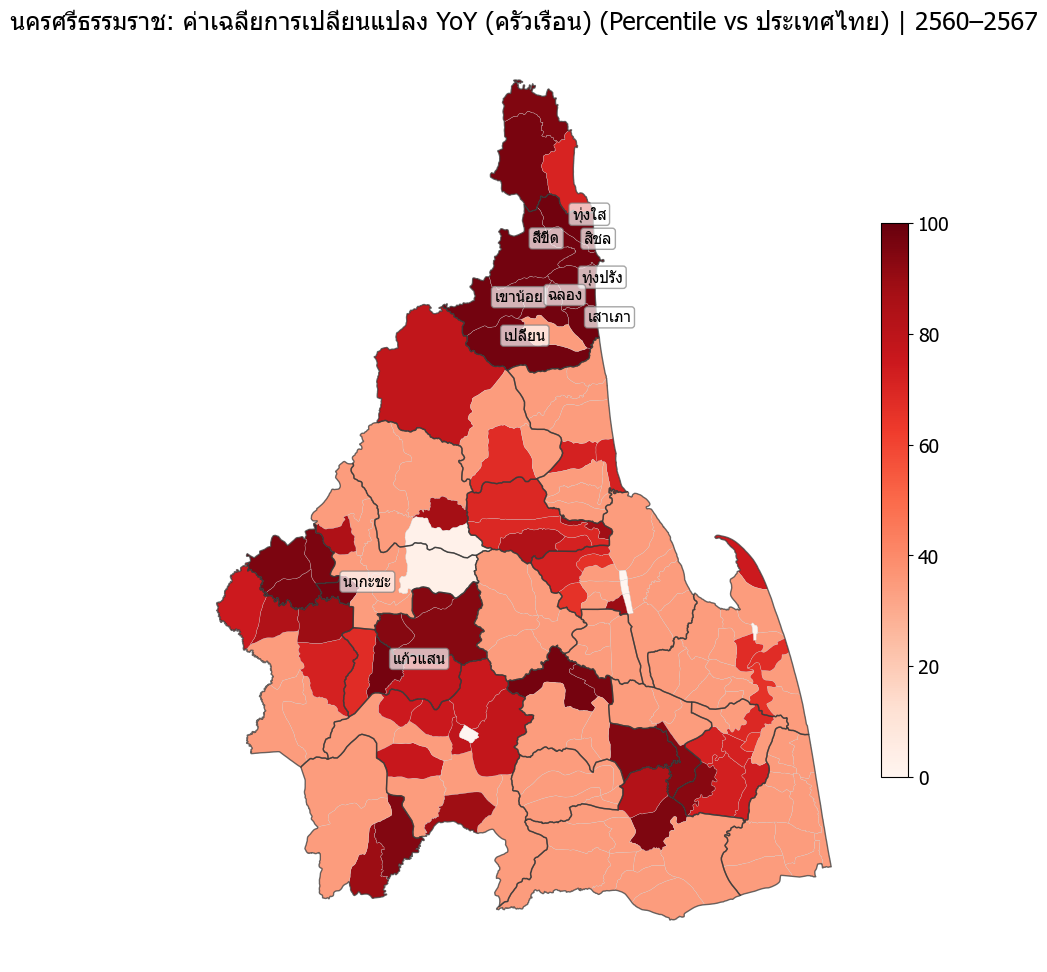

In [9]:
PROVINCE_CODE_NST = '80'

# Filter NST geometry+metrics via code prefix only
nst = map_df.loc[map_df['subdist_cd'].astype(str).str.startswith(PROVINCE_CODE_NST)].copy()
print('Nakhon Si Thammarat rows (geometry):', len(nst))

# Ensure numeric
for c in pct_cols:
    nst[c] = pd.to_numeric(nst[c], errors='coerce').fillna(0.0)

# District boundaries for overlay
districts_nst = None
if 'A_NAME_T' in nst.columns:
    try:
        districts_nst = nst.dissolve(by='A_NAME_T')
    except Exception:
        districts_nst = None

def plot_nst_percentile(metric_pct_col: str, title_th: str) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.set_axis_off()
    ax.set_title(f'นครศรีธรรมราช: {title_th} (Percentile vs ประเทศไทย) | 2560–2567', fontsize=18)

    nst.plot(
        column=metric_pct_col,
        ax=ax,
        cmap='Reds',
        legend=True,
        legend_kwds={'shrink': 0.6, 'fraction': 0.03, 'pad': 0.02},
        vmin=0, vmax=100,
        linewidth=0.2, edgecolor='#CCCCCC',
    )

    if districts_nst is not None:
        try:
            districts_nst.boundary.plot(ax=ax, color='#333333', linewidth=1.0, alpha=0.7)
        except Exception: pass

    # Annotate top 10 tambons within NST by percentile
    top10 = nst.sort_values(metric_pct_col, ascending=False).head(10).copy()
    for _, r in top10.iterrows():
        try:
            pt = r.geometry.representative_point()
            ax.annotate(
                text=_label_tambon(r),
                xy=(pt.x, pt.y), xytext=(3, 3), textcoords='offset points',
                fontsize=11,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='0.5'),
            )
        except Exception: continue
    plt.show()

for col, title_th in chiang_rai_maps:
    plot_nst_percentile(col, title_th)

### 2.2) Nakhon Si Thammarat — histograms of percentile metrics (distribution across tambons)

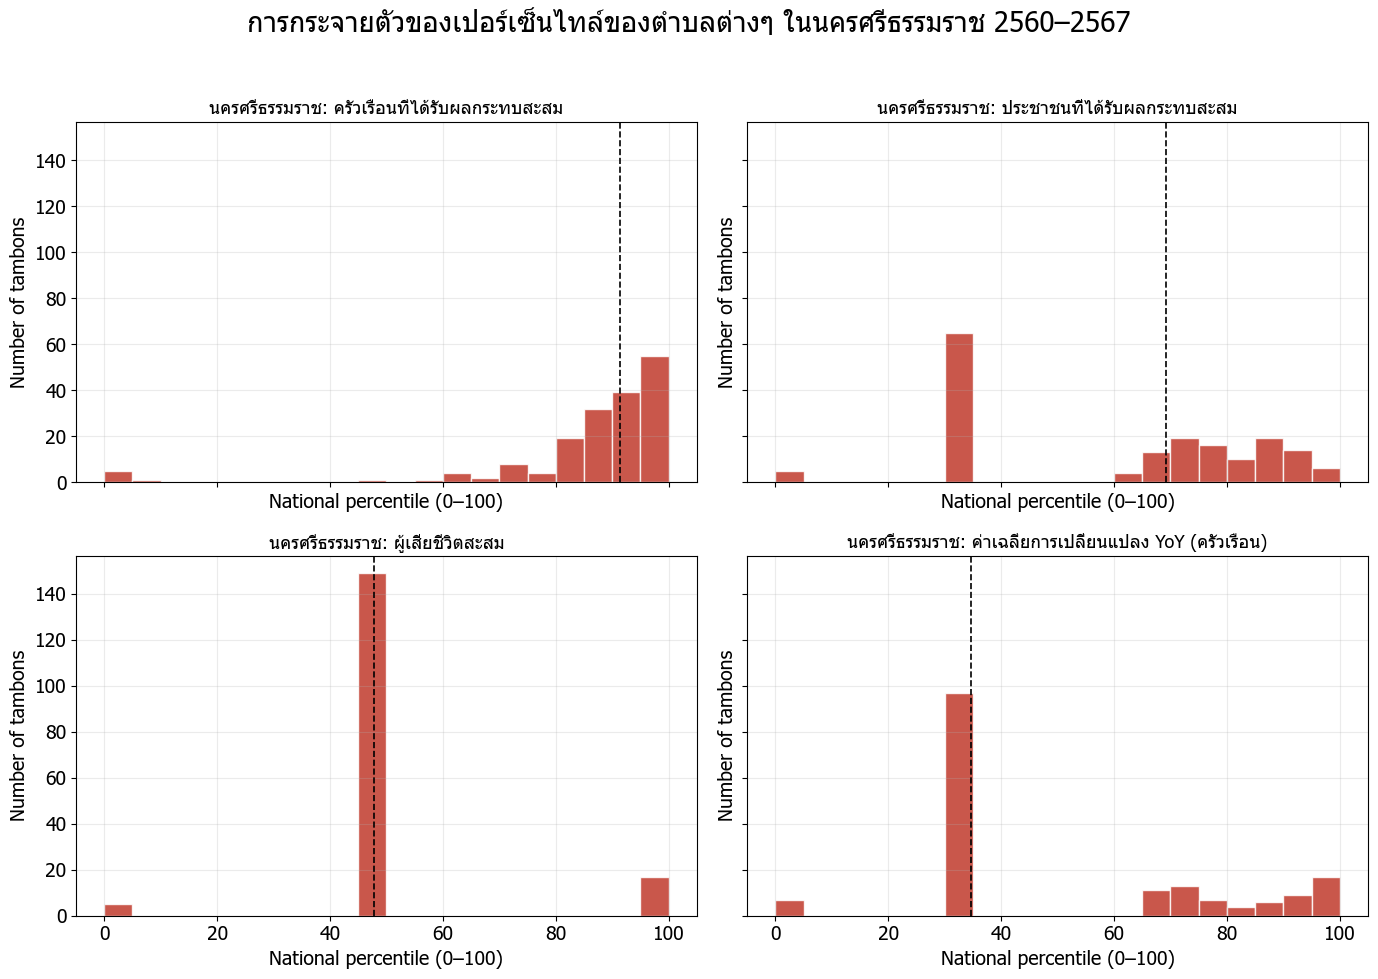

In [10]:
# Histograms for NST percentile metrics
_nst_pct = nst[pct_cols].copy()
_nst_pct = _nst_pct.apply(lambda s: pd.to_numeric(s, errors='coerce')).fillna(0.0).clip(0, 100)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

for i, c in enumerate(pct_cols):
    ax = axes[i]
    vals = _nst_pct[c].dropna().values
    ax.hist(vals, bins=20, range=(0, 100), color='#c0392b', alpha=0.85, edgecolor='white')
    ax.set_title(f'นครศรีธรรมราช: {title_map_th.get(c, c)}', fontsize=13)
    ax.set_xlabel('National percentile (0–100)')
    ax.set_ylabel('Number of tambons')
    ax.grid(True, alpha=0.25)
    if len(vals):
        q50 = np.percentile(vals, 50)
        ax.axvline(q50, color='black', linestyle='--', linewidth=1.2)

plt.suptitle('การกระจายตัวของเปอร์เซ็นไทล์ของตำบลต่างๆ ในนครศรีธรรมราช 2560–2567', fontsize=20)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

### 2.3) Nakhon Si Thammarat focus — absolute impact values

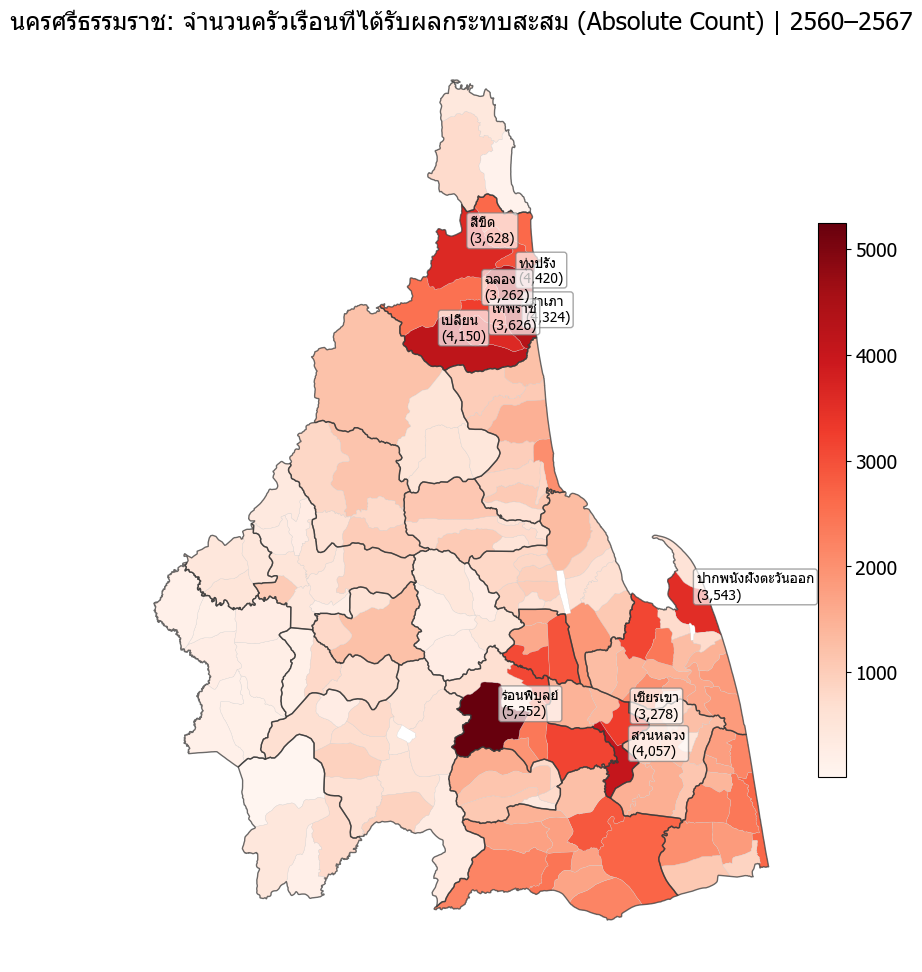

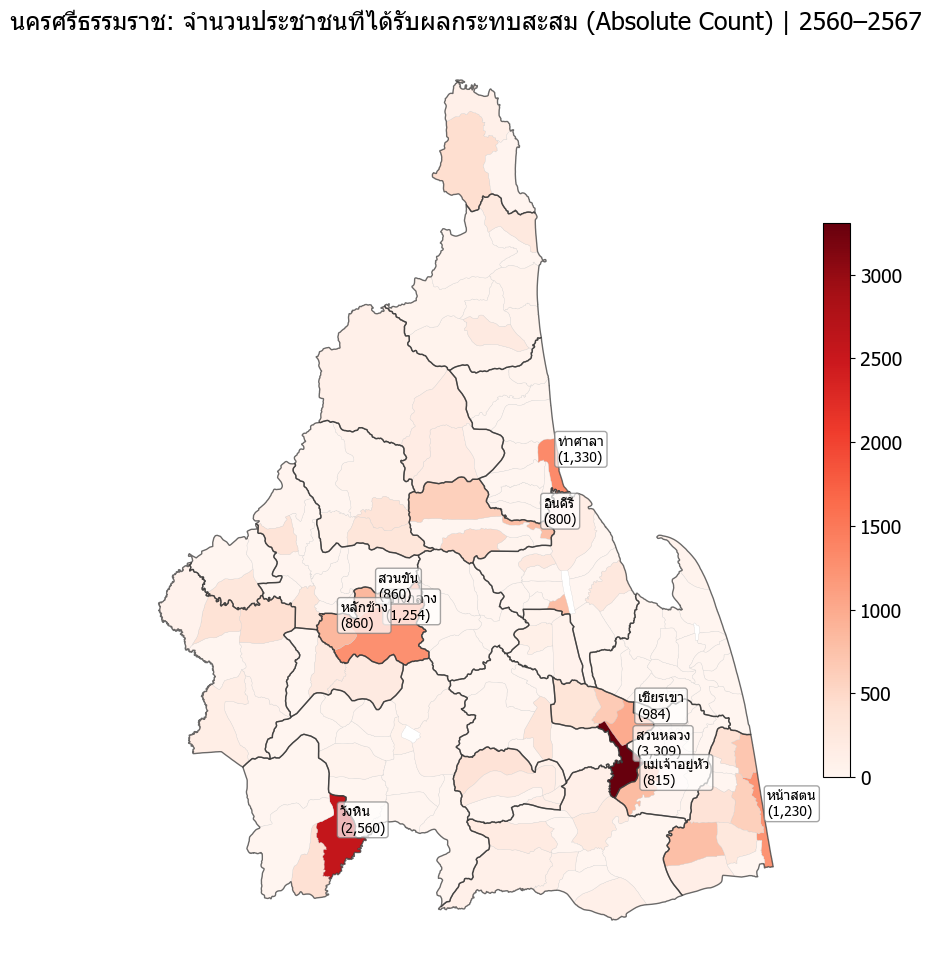

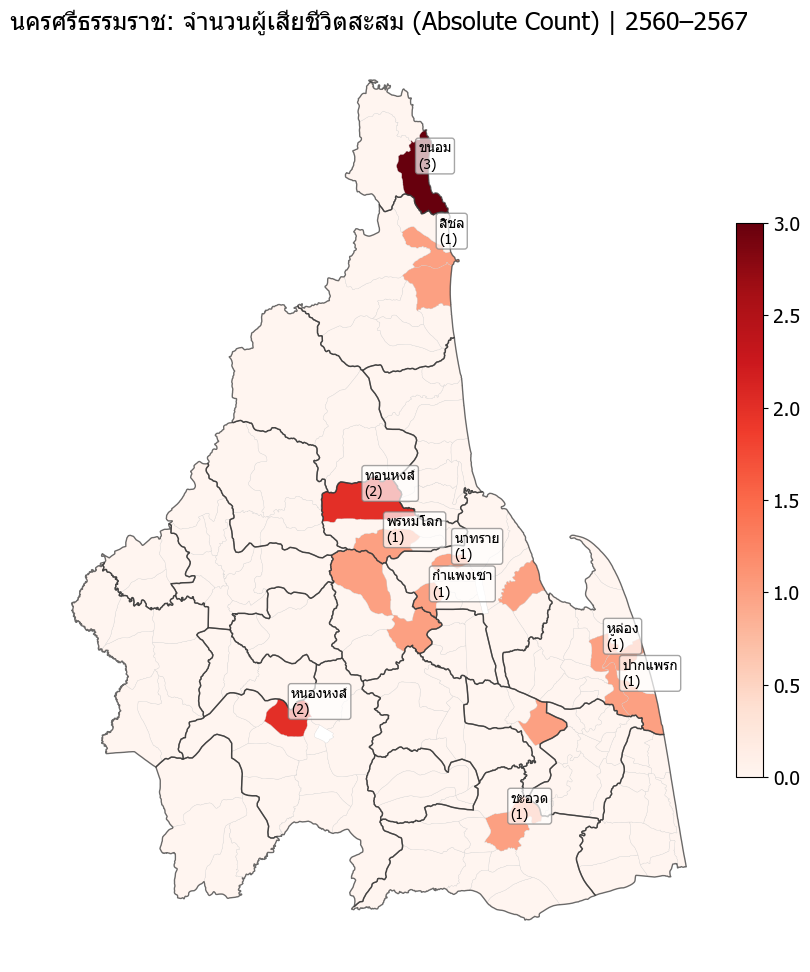

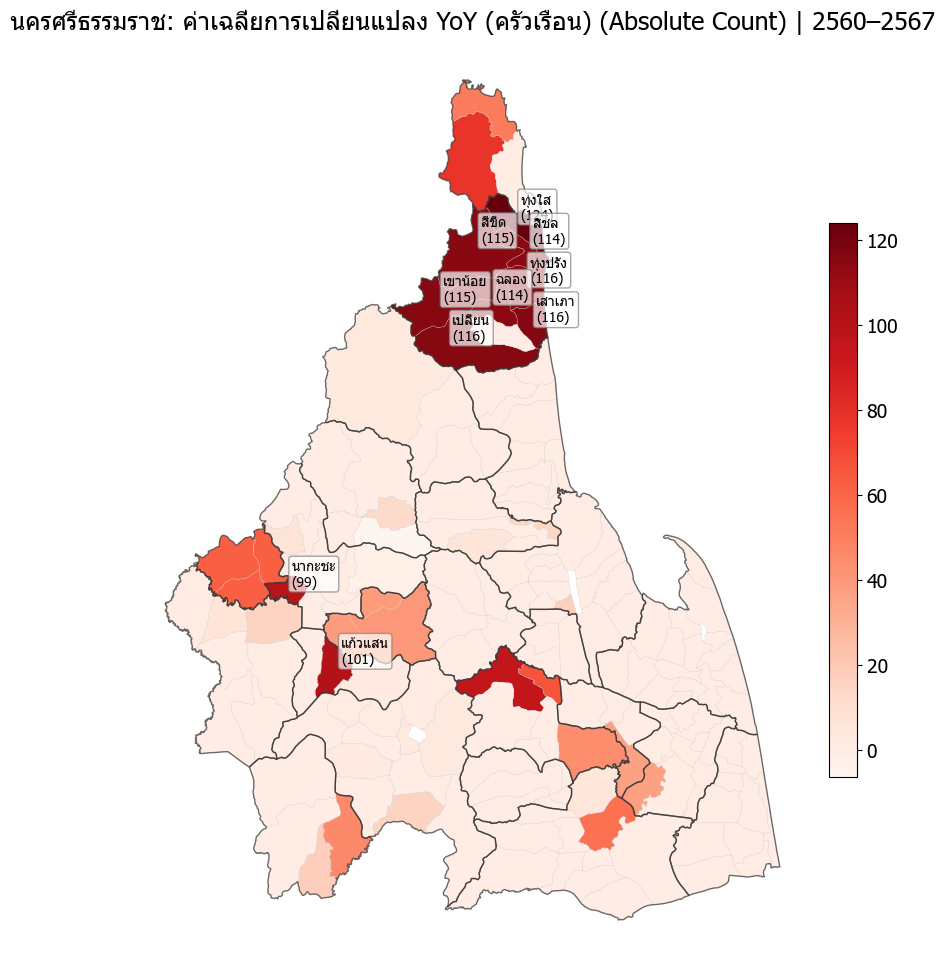

In [11]:
def plot_nst_absolute(metric_col: str, title_th: str) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.set_axis_off()
    ax.set_title(f'นครศรีธรรมราช: {title_th} (Absolute Count) | 2560–2567', fontsize=18)

    nst.plot(
        column=metric_col,
        ax=ax,
        cmap='Reds',
        legend=True,
        legend_kwds={'shrink': 0.6, 'fraction': 0.03, 'pad': 0.02},
        linewidth=0.2, edgecolor='#CCCCCC',
    )

    if districts_nst is not None:
        try:
            districts_nst.boundary.plot(ax=ax, color='#333333', linewidth=1.0, alpha=0.7)
        except Exception: pass

    top10 = nst.sort_values(metric_col, ascending=False).head(10).copy()
    for _, r in top10.iterrows():
        try:
            pt = r.geometry.representative_point()
            val = r[metric_col]
            label = f"{_label_tambon(r)}\n({val:,.0f})" if val >= 1 else _label_tambon(r)
            ax.annotate(
                text=label,
                xy=(pt.x, pt.y), xytext=(3, 3), textcoords='offset points',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='0.5'),
            )
        except Exception: continue
    plt.show()

for col, title_th in abs_metrics:
    if col in nst.columns:
        plot_nst_absolute(col, title_th)

### 2.4) Nakhon Si Thammarat — histograms of absolute metrics

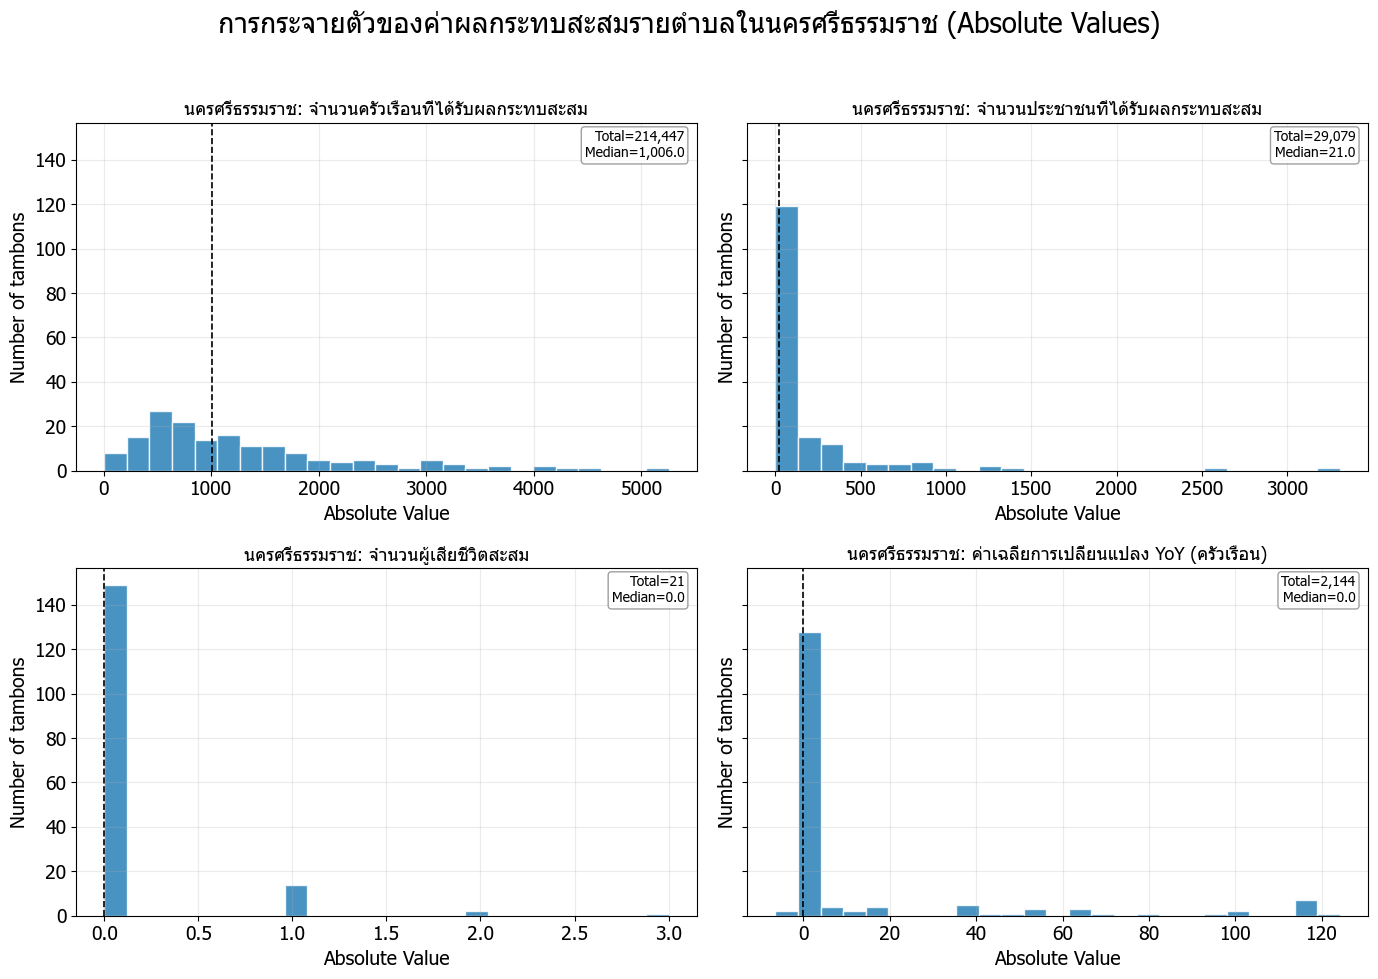

In [12]:
# Histograms for absolute metrics (NST)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.ravel()

for i, (col, title_th) in enumerate(abs_metrics):
    ax = axes[i]
    if col not in nst.columns: continue
    vals = pd.to_numeric(nst[col], errors='coerce').dropna().values
    ax.hist(vals, bins=25, color='#2980b9', alpha=0.85, edgecolor='white')
    ax.set_title(f'นครศรีธรรมราช: {title_th}', fontsize=13)
    ax.set_xlabel('Absolute Value')
    ax.set_ylabel('Number of tambons')
    ax.grid(True, alpha=0.25)
    if len(vals):
        q50 = np.median(vals)
        ax.axvline(q50, color='black', linestyle='--', linewidth=1.2)
        ax.text(0.98, 0.98, f'Total={np.sum(vals):,.0f}\nMedian={q50:,.1f}',
                transform=ax.transAxes, va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.75, ec='0.5'), fontsize=10)

plt.suptitle('การกระจายตัวของค่าผลกระทบสะสมรายตำบลในนครศรีธรรมราช (Absolute Values)', fontsize=20)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 3) Bangkok Specific Analysis
This section applies the same provincial impact analysis to Bangkok (Krung Thep Maha Nakhon).

### 3.1) Bangkok focus — tambon (khwaeng) percentiles (relative to the whole country)

Bangkok rows (geometry): 180


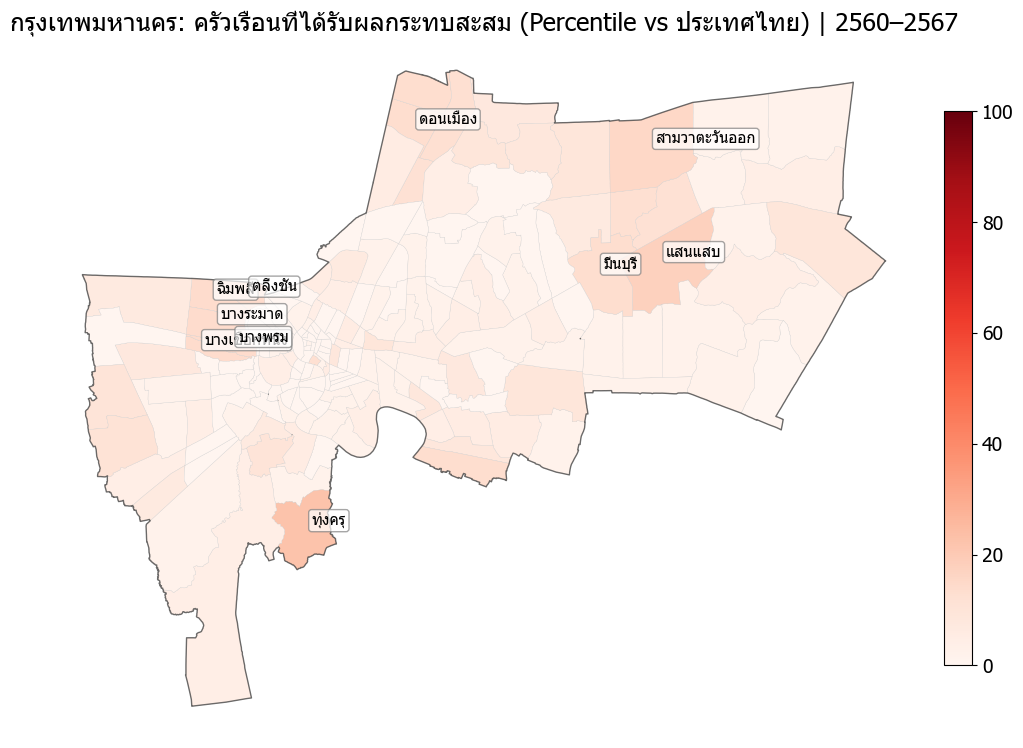

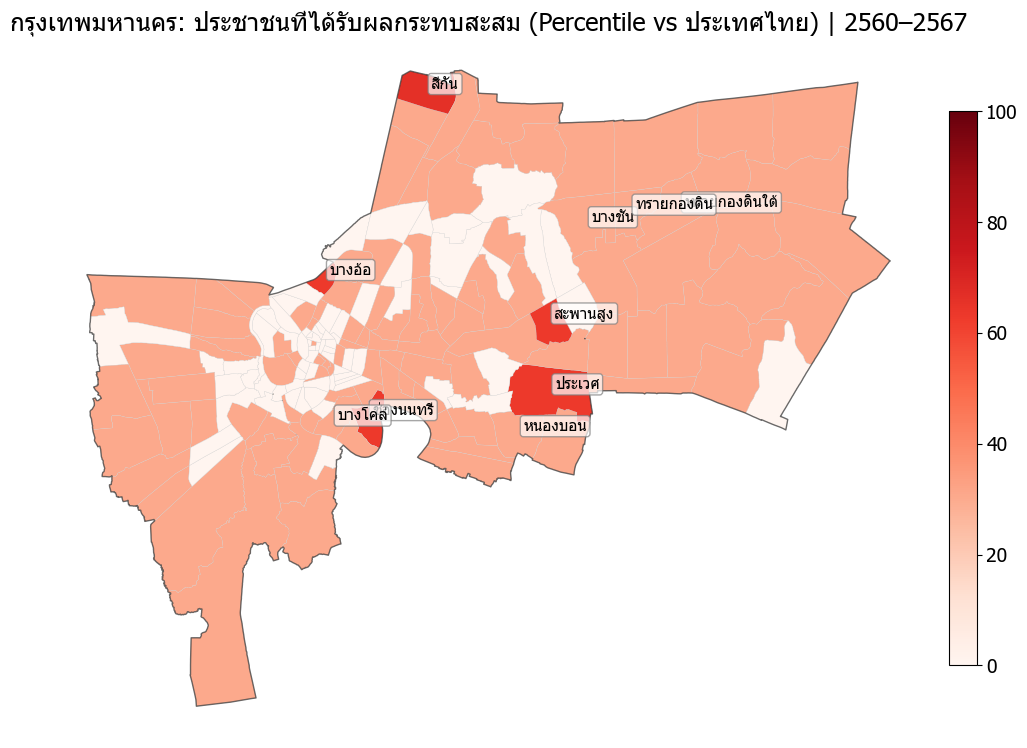

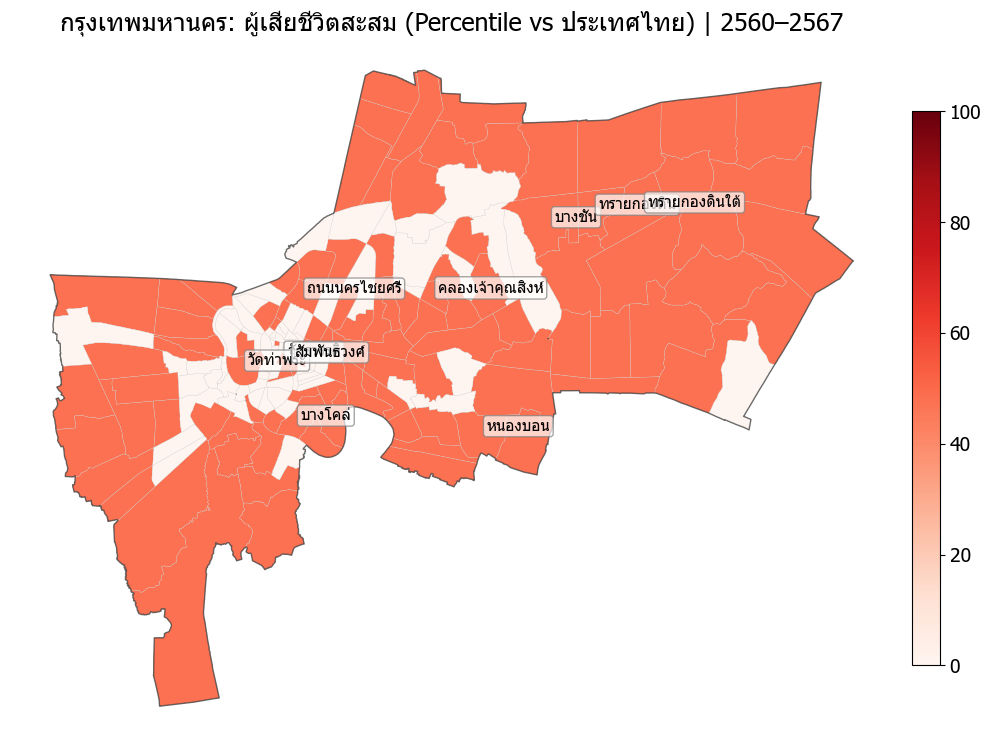

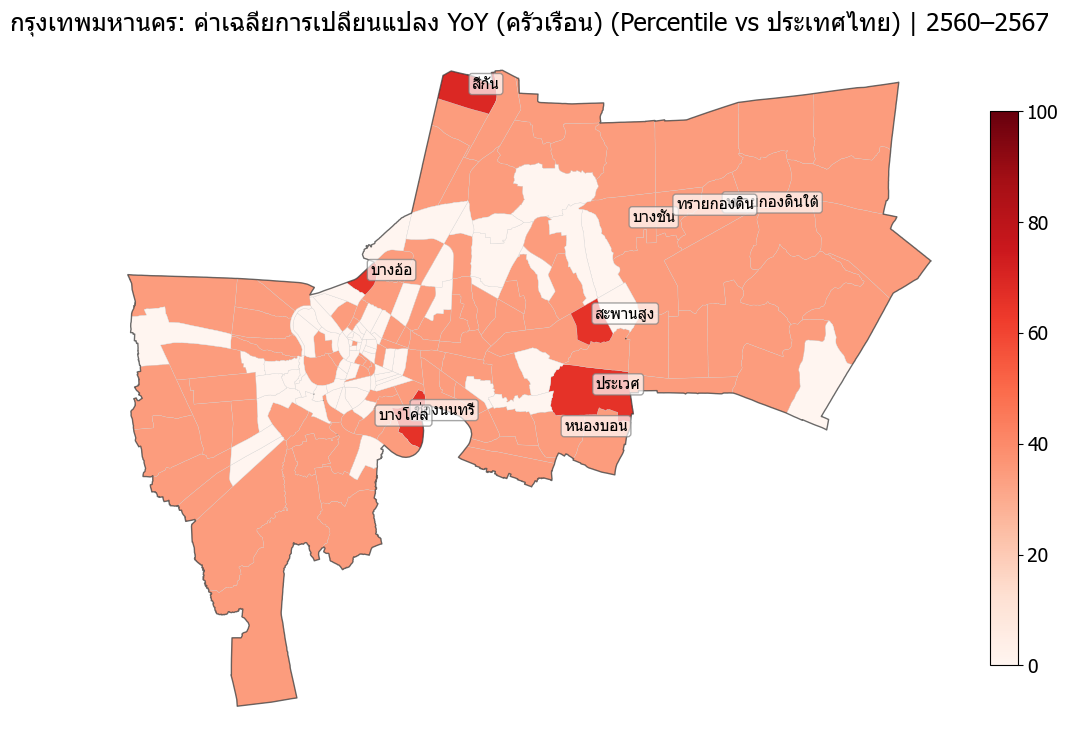

In [13]:
PROVINCE_CODE_BKK = '10'

# Filter BKK geometry+metrics via code prefix only
bkk = map_df.loc[map_df['subdist_cd'].astype(str).str.startswith(PROVINCE_CODE_BKK)].copy()
print('Bangkok rows (geometry):', len(bkk))

# Ensure numeric
for c in pct_cols:
    bkk[c] = pd.to_numeric(bkk[c], errors='coerce').fillna(0.0)

# District boundaries for overlay
districts_bkk = None
if 'A_NAME_T' in bkk.columns:
    try:
        districts_bkk = bkk.dissolve(by='A_NAME_T')
    except Exception:
        districts_bkk = None

def plot_bkk_percentile(metric_pct_col: str, title_th: str) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.set_axis_off()
    ax.set_title(f'กรุงเทพมหานคร: {title_th} (Percentile vs ประเทศไทย) | 2560–2567', fontsize=18)

    bkk.plot(
        column=metric_pct_col,
        ax=ax,
        cmap='Reds',
        legend=True,
        legend_kwds={'shrink': 0.6, 'fraction': 0.03, 'pad': 0.02},
        vmin=0, vmax=100,
        linewidth=0.2, edgecolor='#CCCCCC',
    )

    if districts_bkk is not None:
        try:
            districts_bkk.boundary.plot(ax=ax, color='#333333', linewidth=1.0, alpha=0.7)
        except Exception: pass

    # Annotate top 10 khwaengs within BKK by percentile
    top10 = bkk.sort_values(metric_pct_col, ascending=False).head(10).copy()
    for _, r in top10.iterrows():
        try:
            pt = r.geometry.representative_point()
            ax.annotate(
                text=_label_tambon(r),
                xy=(pt.x, pt.y), xytext=(3, 3), textcoords='offset points',
                fontsize=11,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='0.5'),
            )
        except Exception: continue
    plt.show()

for col, title_th in chiang_rai_maps:
    plot_bkk_percentile(col, title_th)

### 3.2) Bangkok — histograms of percentile metrics (distribution across khwaengs)

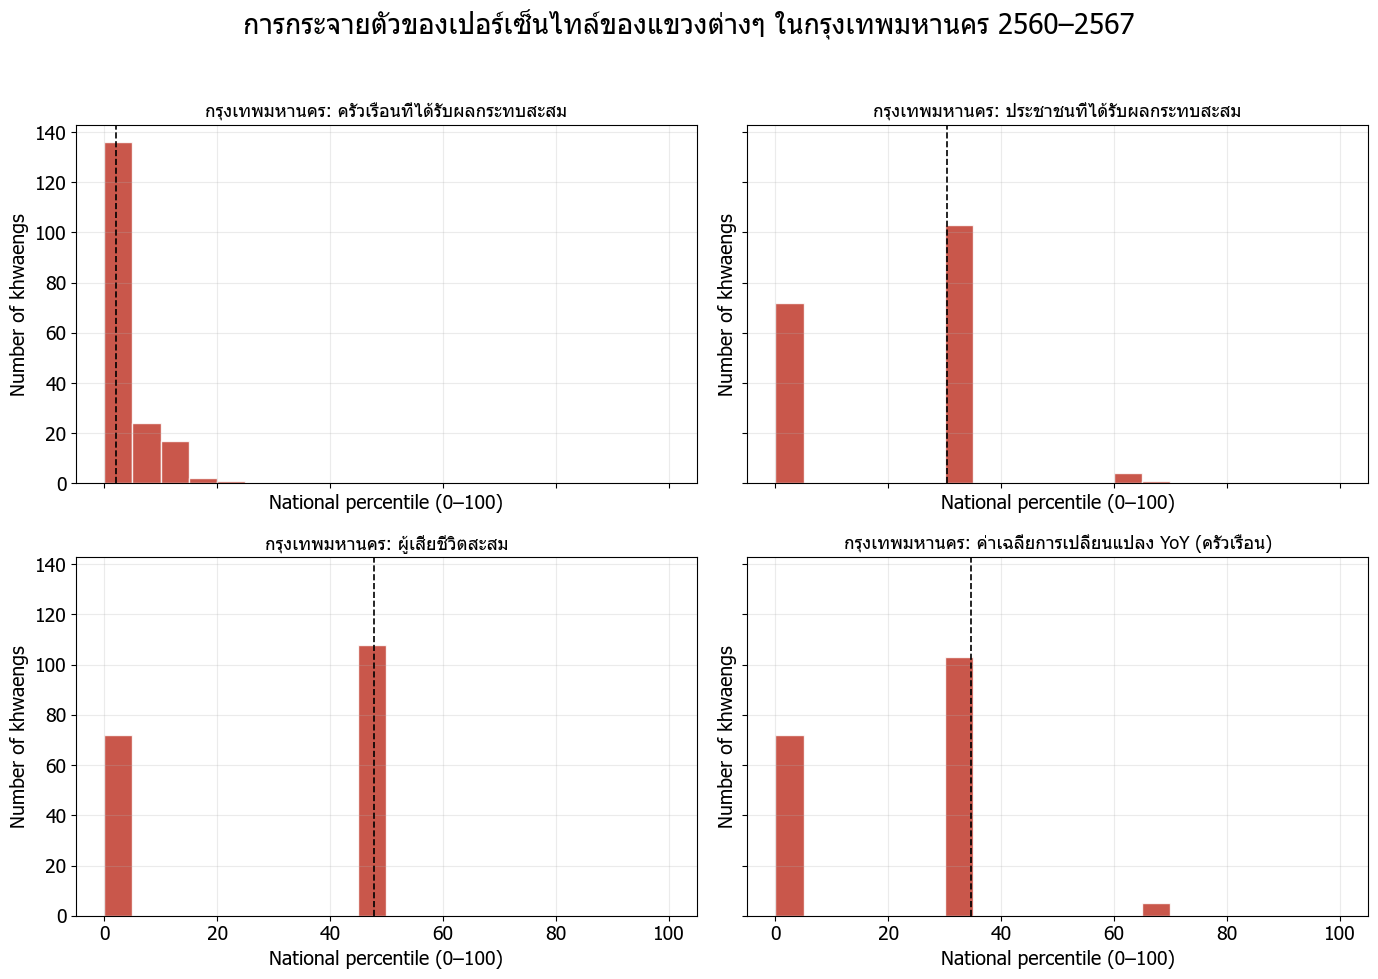

In [14]:
# Histograms for BKK percentile metrics
_bkk_pct = bkk[pct_cols].copy()
_bkk_pct = _bkk_pct.apply(lambda s: pd.to_numeric(s, errors='coerce')).fillna(0.0).clip(0, 100)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

for i, c in enumerate(pct_cols):
    ax = axes[i]
    vals = _bkk_pct[c].dropna().values
    ax.hist(vals, bins=20, range=(0, 100), color='#c0392b', alpha=0.85, edgecolor='white')
    ax.set_title(f'กรุงเทพมหานคร: {title_map_th.get(c, c)}', fontsize=13)
    ax.set_xlabel('National percentile (0–100)')
    ax.set_ylabel('Number of khwaengs')
    ax.grid(True, alpha=0.25)
    if len(vals):
        q50 = np.percentile(vals, 50)
        ax.axvline(q50, color='black', linestyle='--', linewidth=1.2)

plt.suptitle('การกระจายตัวของเปอร์เซ็นไทล์ของแขวงต่างๆ ในกรุงเทพมหานคร 2560–2567', fontsize=20)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

### 3.3) Bangkok focus — absolute impact values

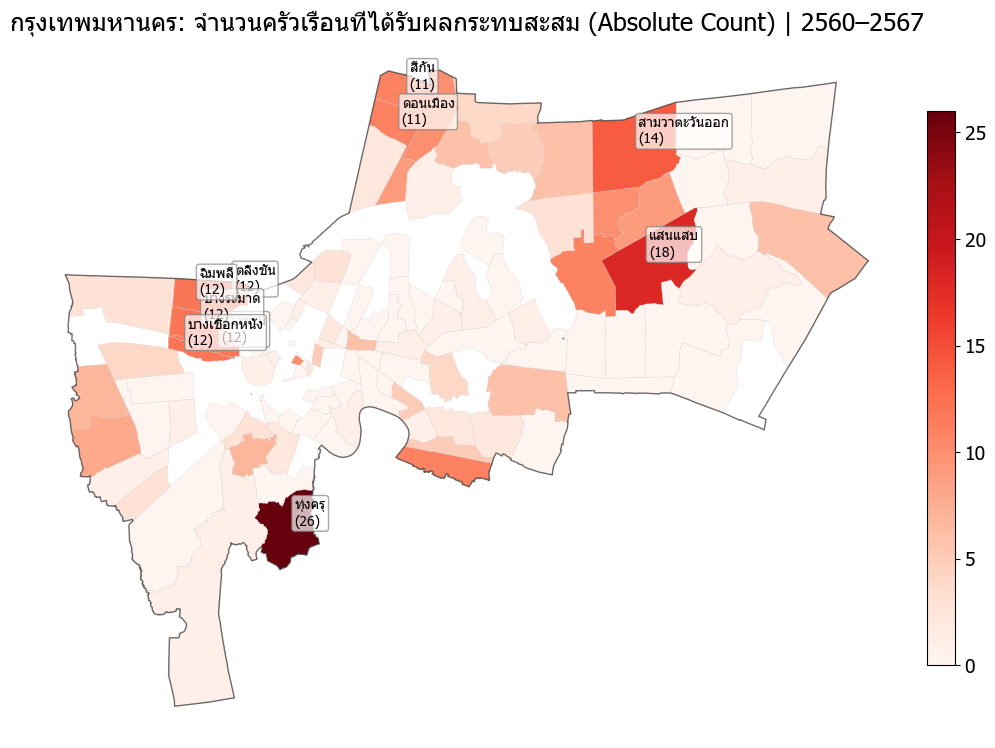

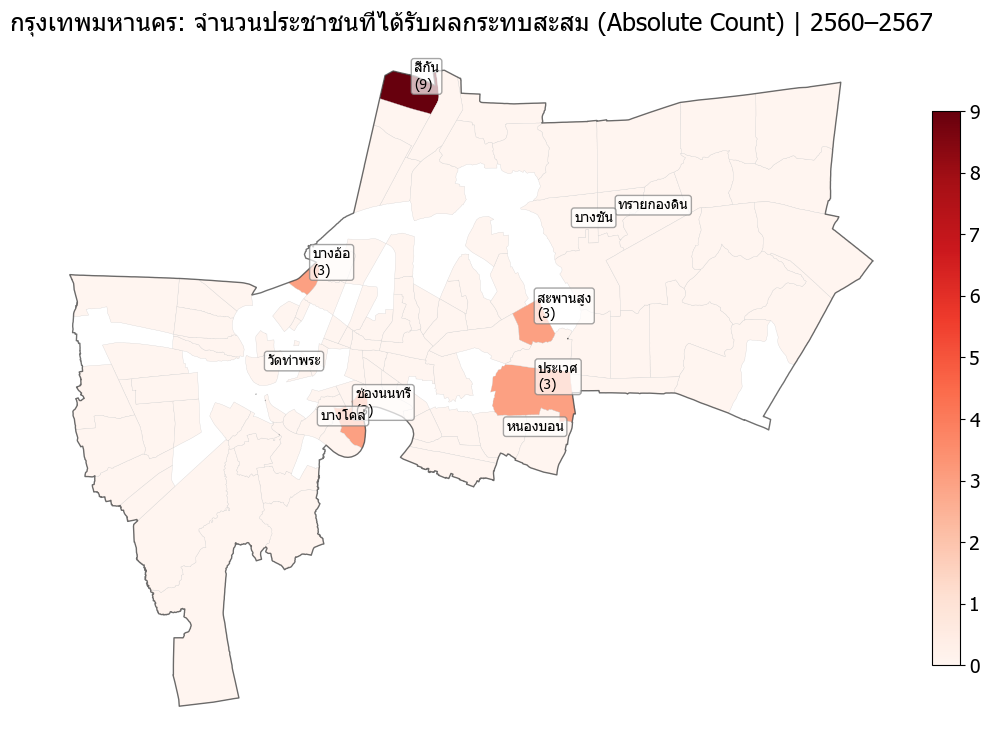

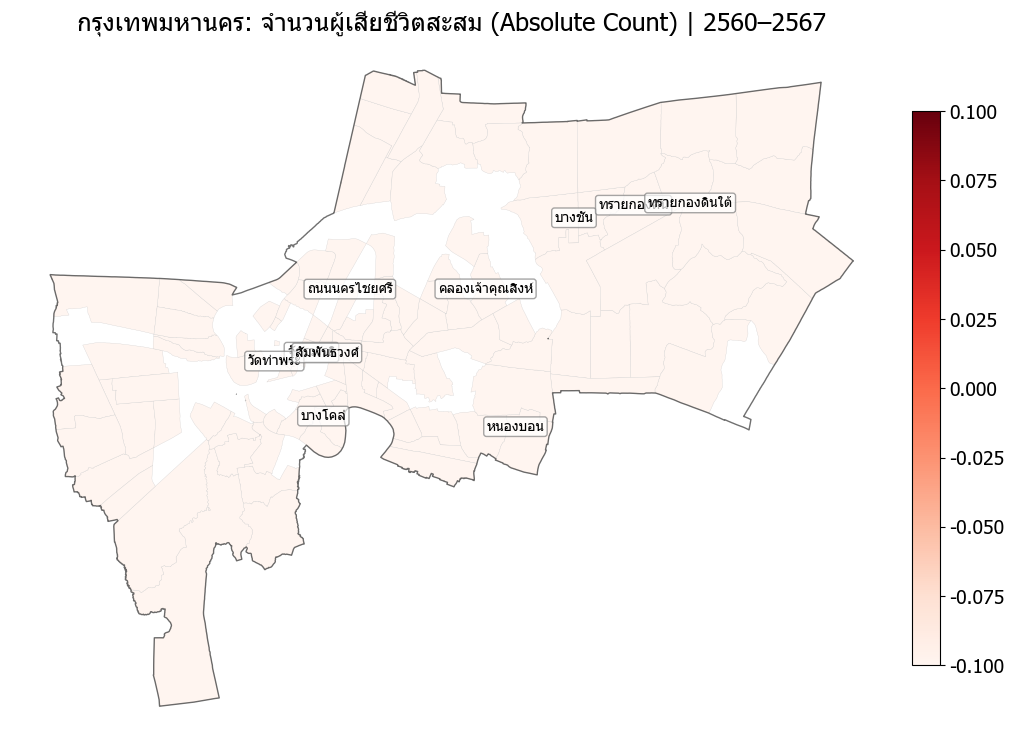

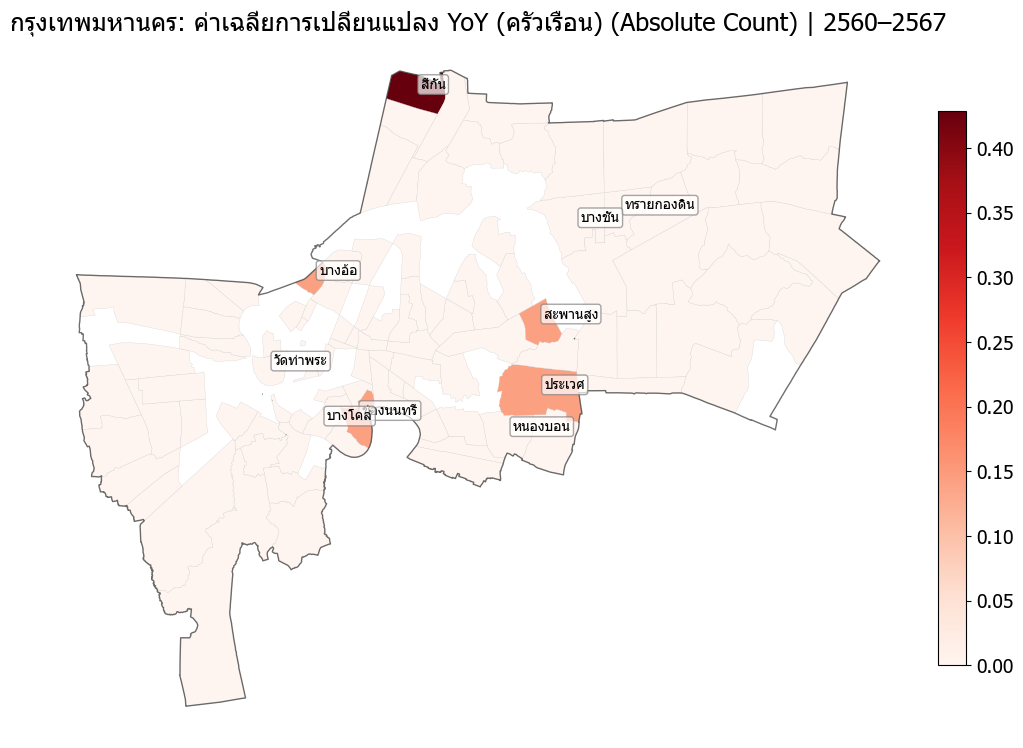

In [15]:
def plot_bkk_absolute(metric_col: str, title_th: str) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.set_axis_off()
    ax.set_title(f'กรุงเทพมหานคร: {title_th} (Absolute Count) | 2560–2567', fontsize=18)

    bkk.plot(
        column=metric_col,
        ax=ax,
        cmap='Reds',
        legend=True,
        legend_kwds={'shrink': 0.6, 'fraction': 0.03, 'pad': 0.02},
        linewidth=0.2, edgecolor='#CCCCCC',
    )

    if districts_bkk is not None:
        try:
            districts_bkk.boundary.plot(ax=ax, color='#333333', linewidth=1.0, alpha=0.7)
        except Exception: pass

    top10 = bkk.sort_values(metric_col, ascending=False).head(10).copy()
    for _, r in top10.iterrows():
        try:
            pt = r.geometry.representative_point()
            val = r[metric_col]
            label = f"{_label_tambon(r)}\n({val:,.0f})" if val >= 1 else _label_tambon(r)
            ax.annotate(
                text=label,
                xy=(pt.x, pt.y), xytext=(3, 3), textcoords='offset points',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='0.5'),
            )
        except Exception: continue
    plt.show()

for col, title_th in abs_metrics:
    if col in bkk.columns:
        plot_bkk_absolute(col, title_th)

### 3.4) Bangkok — histograms of absolute metrics

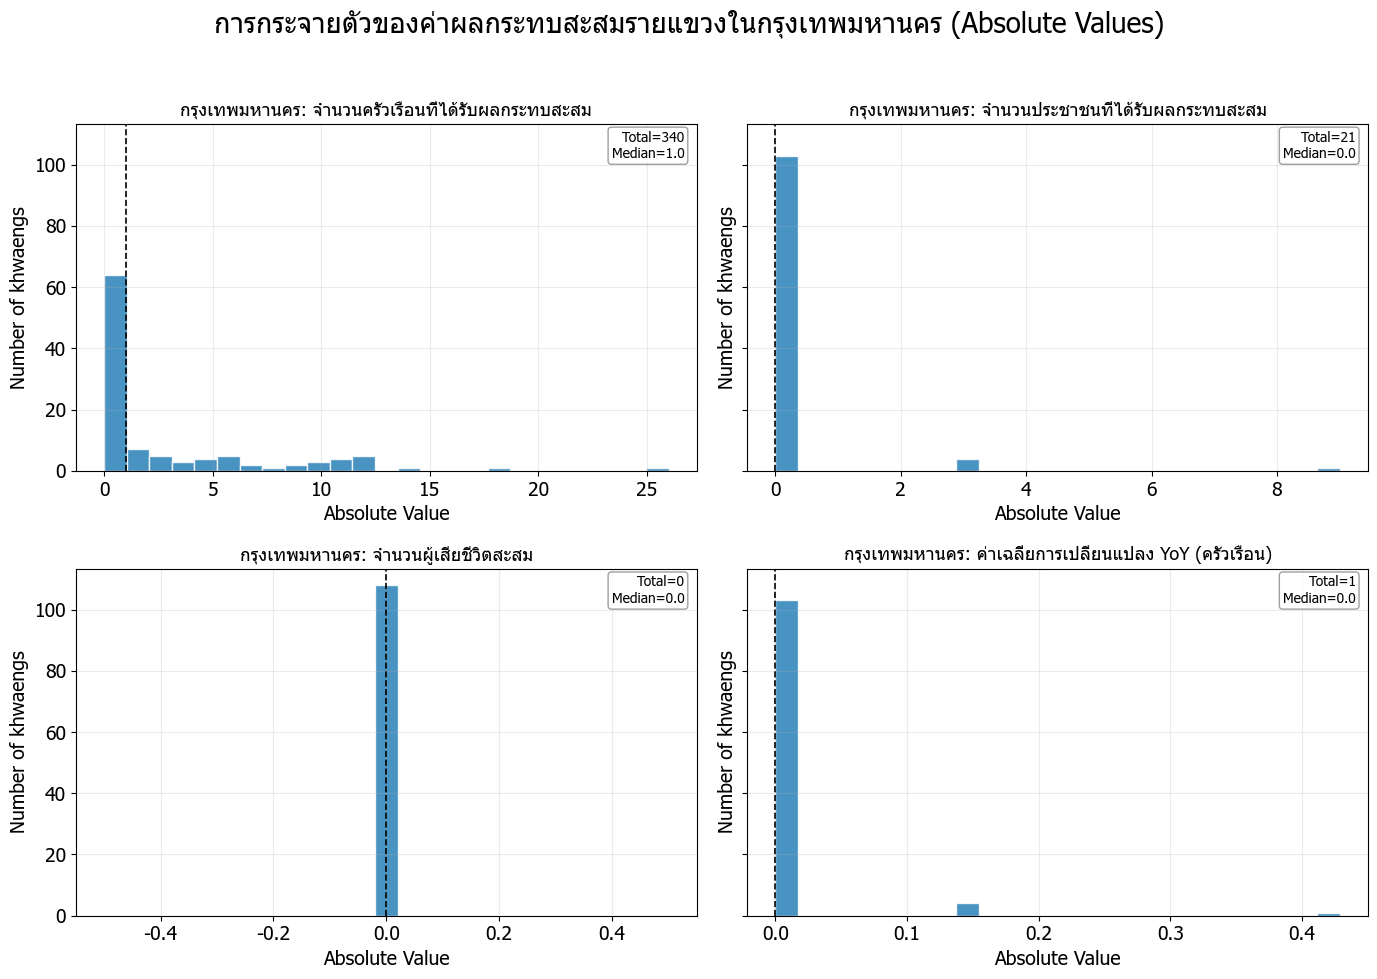

In [16]:
# Histograms for absolute metrics (BKK)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.ravel()

for i, (col, title_th) in enumerate(abs_metrics):
    ax = axes[i]
    if col not in bkk.columns: continue
    vals = pd.to_numeric(bkk[col], errors='coerce').dropna().values
    ax.hist(vals, bins=25, color='#2980b9', alpha=0.85, edgecolor='white')
    ax.set_title(f'กรุงเทพมหานคร: {title_th}', fontsize=13)
    ax.set_xlabel('Absolute Value')
    ax.set_ylabel('Number of khwaengs')
    ax.grid(True, alpha=0.25)
    if len(vals):
        q50 = np.median(vals)
        ax.axvline(q50, color='black', linestyle='--', linewidth=1.2)
        ax.text(0.98, 0.98, f'Total={np.sum(vals):,.0f}\nMedian={q50:,.1f}',
                transform=ax.transAxes, va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.75, ec='0.5'), fontsize=10)

plt.suptitle('การกระจายตัวของค่าผลกระทบสะสมรายแขวงในกรุงเทพมหานคร (Absolute Values)', fontsize=20)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()